In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import json 
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
from shapely.geometry import box
import xarray as xr

In [ ]:
prev = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_mpi_allvars.geojson")

In [19]:
df = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_mpi_allvars.geojson")
df.rename(columns={'MPI distri': 'Multidimensional Poverty Index', '_cookingfu': 'Cooking fuel', '_houseing_': 'Housing', '_asses_dep': 'Assets',
       '_drinkingw': 'Drinking water', '_sanitatio': 'Sanitation', '_electrcit': 'Electricity'
       }, inplace=True)
df.columns

Index(['Name', 'ma_xa', 'ten_xa', 'sap_nhap', 'tru_so', 'loai', 'dtich_km2',
       'dan_so', 'matdo_km2', '_mean', '_median', '_stdev', '_minority',
       '_majority', 'ma_xa_2', 'nor_mn_2', 'nor_md_2', 'id_mean', 'left_mean',
       'top_mean', 'right_mean', 'bottom_mea',
       'Multidimensional Poverty Index', 'MPI dist_1', 'DIEN_TICH_',
       'DAN_SO_mea', 'Cooking fuel', 'Housing', 'Assets', 'Drinking water',
       'Sanitation', 'Electricity', 'geometry'],
      dtype='object')

In [20]:
df[['Name','ma_xa','geometry']].to_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_communes.geojson", driver='GeoJSON')

In [18]:
mpi_cols = ['Multidimensional Poverty Index', 'Cooking fuel', 'Housing', 'Assets', 'Drinking water',
       'Sanitation', 'Electricity']

df_long = df.drop(columns='geometry').melt(
    id_vars='Name',
    value_vars=mpi_cols,
    var_name='Variable',
    value_name='Value'
).dropna(subset=['Value'])

df_long['Value'] = df_long['Value'].round(2)

out_csv = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_communes_MPI_long.csv"
df_long.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print(f"Rows: {len(df_long)}, Variables: {df_long['Variable'].unique().tolist()}")
df_long.head(10)

Saved: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_communes_MPI_long.csv
Rows: 882, Variables: ['Multidimensional Poverty Index', 'Cooking fuel', 'Housing', 'Assets', 'Drinking water', 'Sanitation', 'Electricity']


,Name,Variable,Value
0,An Khánh,Multidimensional Poverty Index,0.67
1,Ba Đình,Multidimensional Poverty Index,0.22
2,Ba Vì,Multidimensional Poverty Index,0.37
3,Bạch Mai,Multidimensional Poverty Index,0.34
4,Bất Bạt,Multidimensional Poverty Index,0.37
5,Bát Tràng,Multidimensional Poverty Index,0.63
6,Bình Minh,Multidimensional Poverty Index,0.52
7,Bồ Đề,Multidimensional Poverty Index,0.35
8,Cầu Giấy,Multidimensional Poverty Index,0.43
9,Chương Dương,Multidimensional Poverty Index,0.54


In [46]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/EcoFoodSystems_indicator_architecture - 260326 - Hanoi_rewritten_descriptions.csv")
df

,EcoFoodSystems Dashboard,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,This sheet serves as the MASTER LIST of all indicators proposed for the dashboard. It defines how indicators are organised within the dashboard structure.,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,#,Affordable diets,Sustainable diets,Healthier diets,NaN,Domain / Sub-theme,Indicator name,Definition (what the indicator measures),Relevance (why it matters for the project),Unit of measurement,...,Data source,Method (calculation or derivation),Years available,Update frequency,Limitations,Responsible researcher,Data accessibility (open/internal/restricted),Notes,Status,NaN
1,#,Affordable diets,Sustainable diets,Healthier diets,Theme,Domain / Sub-theme,Indicator name,Definition (what the indicator measures),Relevance (why it matters for the project),Unit of measurement,...,"If city level, which?",Data source,Method (calculation or derivation),Years available,Update frequency,Limitations,Responsible researcher,Data accessibility (open/internal/restricted),Notes,Status
2,1,NaN,NaN,x,Health,Nutrition & Health,Prevalence of stuntig for under 5,Measures the percentage of children aged 0-59 ...,This indicator captures chronic undernutrition...,HAZ score,...,Nutrition Survailance (NIN),(Number of children 0–59 months with HAZ < -2 ...,2010-2024,Annually,NaN,Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
3,2,NaN,NaN,x,NaN,Nutrition & Health,Prevalence of wasting for under 5,Measures the percentage of children aged 0-59 ...,This indicator reflects acute undernutrition a...,WHZ score,...,Nutrition Survailance (NIN),(Number of children 0–59 months with WHZ < -2 ...,2010-2024,Annually,NaN,Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
4,3,NaN,NaN,x,NaN,Nutrition & Health,Prevalence of underweight for under 5,Measures the percentage of children aged 0-59 ...,This indicator provides an overall measure of ...,WAZ score,...,Nutrition Survailance (NIN),(Number of children 0–59 months with WAZ < -2 ...,2010-2024,Annually,NaN,Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
5,4,NaN,NaN,x,Health,Nutrition & Health,Prevalence of obesity and overweight for under 5,Measures the percentage of children aged 0-59 ...,This indicator highlights early exposure to un...,BMI-for-age,...,Nutrition Survailance (NIN),(Number of children 0–59 months with WHZ > +2 ...,2010-2023,Annually,NaN,Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
6,5,NaN,NaN,x,NaN,Nutrition & Health,Prevalence of underweight for women,Measures the percentage of women aged 15-49 ye...,This indicator reflects inadequate dietary int...,BMI (kg/m²),...,Nutrition Survailance (NIN),(Number of women with BMI < 18.5 / Total numbe...,2010-2023,Annually,NaN,Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
7,6,NaN,NaN,x,NaN,Nutrition & Health,Prevalence of obesity and overweight for women,Measures the percentage of adult women classif...,This indicator captures the diet-related non-c...,BMI (kg/m²),...,Nutrition Survailance (NIN),(Number of women with BMI ≥ 23 / Total number ...,2010-2023,NaN,"based on small-scale, isolated research.",Ky Hoang,Open,NaN,Displayed in Dashboard,NaN
8,7,x,NaN,NaN,NaN,Food Environments,Cost of affordable diets,Planned indicator to measure the minimum cost ...,This indicator will help assess whether staple...,Data not available yet,...,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,NaN
9,8,x,NaN,NaN,NaN,Food Environments,Cost and affordability of healthy diets,Planned indicator to measure the cost of a die...,This indicator will support analysis of whethe...,Data not available yet,...,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available yet,Data not available ye

In [24]:
lulc = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_lulc_summary.csv")

cat_dict = {
1: 'Water',
2: 'Urban/Built-up',
3: 'Rice',
4: 'Other Crops',
5: 'Grass/Shrub',
6: 'Woody Crops/Orchards',
7: 'Barren',
8: 'Evergreen Forest',
9: 'Deciduous Forest',
10: 'Plantation Forest',
11: 'Mangrove Forest',
12: 'Aquaculture'}

keep_cols = ['Name','ma_xa'] + list(cat_dict.values())

lulc = lulc[keep_cols] 
lulc.set_index(['Name','ma_xa'], inplace=True)
lulc = lulc * 100
lulc.reset_index(inplace=True)
lulc.head()
lulc.to_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/lulc_stats.csv", index=False)

In [40]:
hanoi_json_path = '/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_districts_MPI.geojson'
hanoi = gpd.read_file(hanoi_json_path)
hanoi.head()

,Dist_Name,Dist_name,Dis_code,MPI_LS,Multidimensional Poverty Index,Cooking fuel,Housing,Assets,Drinking water,Sanitation,Electricity,depri_cata,id,Com_cod,Dist_cod,geometry
0,Ba Dinh,Ba Dinh,1,0.11,0.06,51.52,1.62,10.63,0.34,0.36,0.0,0-10,None,1,1,"POLYGON ((105.84332 21.02949, 105.84302 21.029..."
1,Ba Vi,Ba Vi,271,0.24,0.63,91.19,4.66,5.75,32.61,7.94,0.0,60-70,None,9709,271,"POLYGON ((105.47479 21.17208, 105.47342 21.171..."
2,Bac Tu Liem,Bac TuLiem,21,0.14,0.19,66.65,1.70,11.80,2.81,0.07,0.0,10-20,None,595,21,"POLYGON ((105.74149 21.10745, 105.74255 21.106..."
3,Cau Giay,\r\nCau Giay,5,0.09,0.00,39.46,1.03,16.25,0.09,0.17,0.0,0-10,None,163,5,"POLYGON ((105.77002 21.04372, 105.77114 21.044..."
4,Chuong My,Chuong My,277,0.28,0.81,93.99,0.60,4.38,63.40,4.67,0.1,80-90,None,10066,277,"POLYGON ((105.57911 20.91592, 105.57943 20.915..."


In [44]:
lulc_stats = pd.concat([hanoi.set_index("Dis_code")[['geometry','Dist_Name']], lulc.set_index("Dis_code")], axis=1, join="inner").reset_index()
lulc_stats_gdf = gpd.GeoDataFrame(lulc_stats, geometry="geometry", crs="EPSG:4326")
lulc_stats_gdf.dtypes

Dis_code                 float64
geometry                geometry
Dist_Name                 object
Dist_name                 object
Water                    float64
Urban/Built-up           float64
Rice                     float64
Other Crops              float64
Grass/Shrub              float64
Woody Crops/Orchards     float64
Barren                   float64
Evergreen Forest         float64
Deciduous Forest         float64
Plantation Forest        float64
Mangrove Forest          float64
Aquaculture              float64
dtype: object

In [42]:
lulc_stats_gdf.to_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/lulc_stats_gdf.geojson", driver="GeoJSON")

<Axes: >

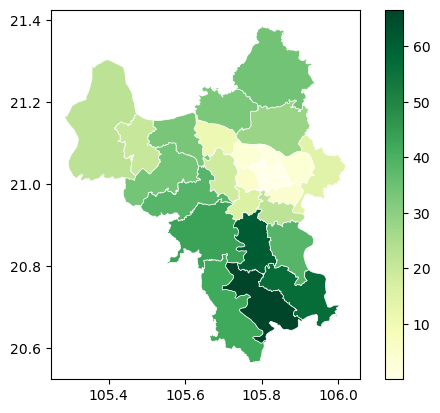

In [39]:
lulc_stats_gdf.plot(column='Rice', cmap='YlGn', legend=True, edgecolor='white', linewidth=0.5)

In [11]:
da = xr.open_dataarray("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/merged.tif")
da_clip = da.sel(x=slice(bbox.bounds[0], bbox.bounds[2]), y=slice(bbox.bounds[3], bbox.bounds[1]))

/Users/jemimaofarrell/miniconda3/envs/jofenv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3171: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  result = runner(coro)
/Users/jemimaofarrell/miniconda3/envs/jofenv/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:243: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Saved COG: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/hanoi_lulc_clipped_cog.tif


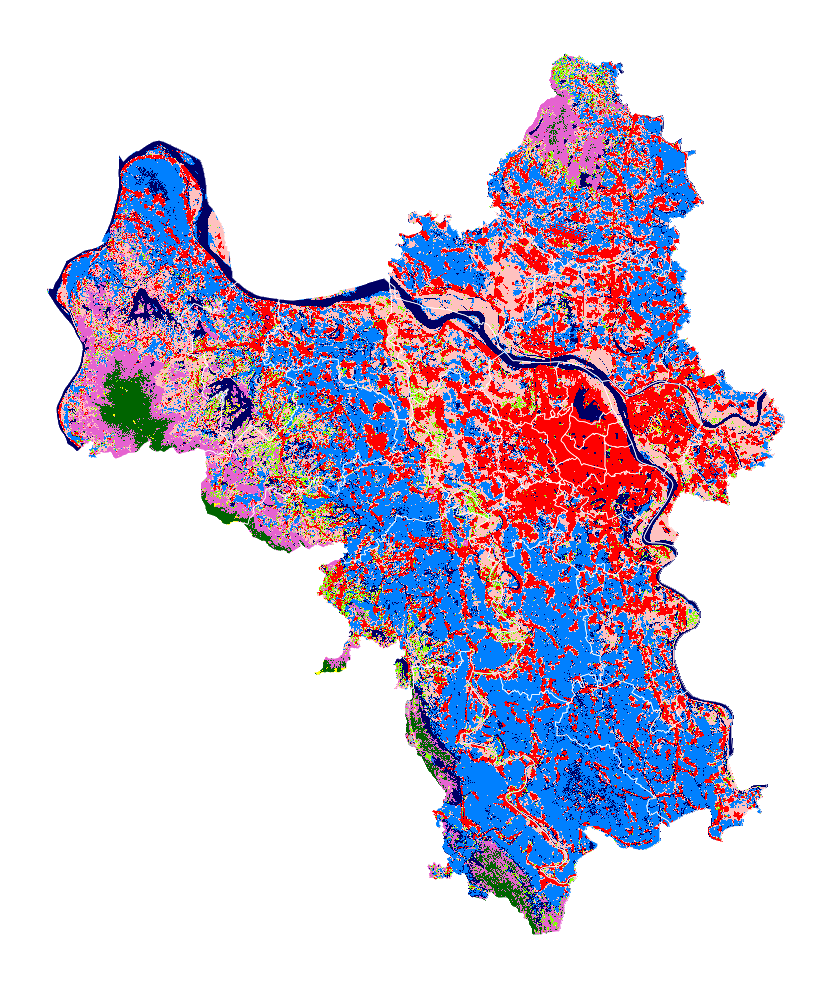

Saved clipped TIFF: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/hanoi_lulc_clipped.tif
Saved overlay PNG: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/hanoi_lulc_clipped_overlay.png
Saved bounds JSON: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/hanoi_lulc_clipped_bounds.json


In [17]:
import json
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401  (activates .rio accessor)
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# -------------------------
# Paths
# -------------------------
hanoi_json_path = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_districts_MPI.geojson"
in_tif = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs/merged.tif"

out_dir = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Other_LULC/2020VNM_v23.09_10m/hanoi_tifs"
out_clip_tif = f"{out_dir}/hanoi_lulc_clipped.tif"
out_clip_cog = f"{out_dir}/hanoi_lulc_clipped_cog.tif"   # optional if GDAL COG driver is available
out_png = f"{out_dir}/hanoi_lulc_clipped_overlay.png"
out_bounds = f"{out_dir}/hanoi_lulc_clipped_bounds.json"

# -------------------------
# Load polygon and raster
# -------------------------
hanoi = gpd.read_file(hanoi_json_path).to_crs("EPSG:4326")
hanoi["geometry"] = hanoi.geometry.buffer(0)
hanoi = hanoi[hanoi.geometry.is_valid & ~hanoi.geometry.is_empty]

da = xr.open_dataarray(in_tif)

# Ensure CRS exists and matches polygon CRS
if da.rio.crs is None:
    da = da.rio.write_crs("EPSG:4326")

if str(da.rio.crs) != "EPSG:4326":
    da = da.rio.reproject("EPSG:4326")

# If there is a band dimension, keep single-band array for display/export
if "band" in da.dims:
    da = da.squeeze("band", drop=True)

# -------------------------
# Clip to full Hanoi polygon
# -------------------------
da_clip_poly = da.rio.clip(hanoi.geometry, hanoi.crs, drop=True)

# Save clipped GeoTIFF
da_clip_poly.rio.to_raster(
    out_clip_tif,
    compress="LZW",
    tiled=True
)

# Optional COG export (works if rasterio/GDAL supports COG driver)
try:
    da_clip_poly.rio.to_raster(
        out_clip_cog,
        driver="COG",
        compress="LZW",
        overview_resampling="nearest",
        blocksize=512
    )
    print(f"Saved COG: {out_clip_cog}")
except Exception as e:
    print(f"COG export skipped: {e}")

# -------------------------
# Build categorical PNG with transparency for NoData
# -------------------------
# Class RGB mapping (your scheme)
class_rgb = {
    0:  (0, 0, 0),          # NoData (transparent below)
    1:  (0, 0, 100),
    2:  (255, 0, 0),
    3:  (0, 128, 255),
    4:  (255, 193, 191),
    5:  (255, 255, 0),
    6:  (128, 255, 0),
    7:  (186, 186, 186),
    8:  (0, 100, 0),
    9:  (171, 218, 157),
    10: (229, 99, 208),
    11: (128, 100, 0),
    12: (77, 104, 255),
}

colors = np.zeros((256, 4), dtype=float)
colors[:, :] = np.array([0.70, 0.70, 0.70, 1.0])  # 13-255 unclassified gray
colors[0] = np.array([0, 0, 0, 0])                # no data transparent
for k, rgb in class_rgb.items():
    colors[k, :3] = np.array(rgb) / 255.0
    colors[k, 3] = 1.0

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 256.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(
    da_clip_poly.values,
    cmap=cmap,
    norm=norm,
    extent=[float(da_clip_poly.x.min()), float(da_clip_poly.x.max()),
            float(da_clip_poly.y.min()), float(da_clip_poly.y.max())],
    origin="upper",
    interpolation="nearest"
)
hanoi.boundary.plot(ax=ax, edgecolor="white", linewidth=0.5)
ax.axis("off")
plt.tight_layout()
plt.savefig(out_png, dpi=720, bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()

# Save bounds for map overlays
bounds_payload = {
    "west": float(da_clip_poly.x.min()),
    "east": float(da_clip_poly.x.max()),
    "south": float(da_clip_poly.y.min()),
    "north": float(da_clip_poly.y.max()),
    "crs": "EPSG:4326"
}
with open(out_bounds, "w") as f:
    json.dump(bounds_payload, f, indent=2)

print(f"Saved clipped TIFF: {out_clip_tif}")
print(f"Saved overlay PNG: {out_png}")
print(f"Saved bounds JSON: {out_bounds}")

In [ ]:
hanoi_resilience_dir = os.path.join("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/")

# Paths for cached EMDAT parquet files (resilience)
EMDAT_COUNTS_PQ = os.path.join(hanoi_resilience_dir, "emdat_counts.parquet")
EMDAT_TOTALS_PQ = os.path.join(hanoi_resilience_dir, "emdat_totals.parquet")

def _load_emdat_cached():
    if os.path.exists(EMDAT_COUNTS_PQ) and os.path.exists(EMDAT_TOTALS_PQ):
        df_counts = pd.read_parquet(EMDAT_COUNTS_PQ)
        df_totals = pd.read_parquet(EMDAT_TOTALS_PQ)
        return df_counts, df_totals
    return None, None

def build_resilience_figure_from_cache(df_counts=None, df_totals=None, size_max=40):
    if df_counts is None or df_totals is None:
        df_counts, df_totals = _load_emdat_cached()
        if df_counts is None or df_totals is None:
            empty = go.Figure()
            empty.add_annotation(text="EMDAT cache not found", showarrow=False, xref='paper', yref='paper', x=0.5, y=0.5, font=dict(size=12))
            empty.update_layout(margin=dict(l=10, r=10, t=10, b=10), height=420)
            return empty

    scatter_fig = px.scatter(
        df_counts,
        x='Year',
        y='Disaster Subtype',
        color='Disaster Subgroup',
        size='Count',
        size_max=size_max,
        hover_data={'Count': True, 'Year': True, 'Disaster Subgroup': True}
    )
    scatter_fig.update_traces(showlegend=False)

    bar_fig = px.bar(
        df_totals,
        x='Year',
        y='TotalAffected',
        labels={'TotalAffected': 'Total Affected (people)'},
        color_discrete_sequence=['orangered']
    )

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.9, 0.4], vertical_spacing=0.06)
    for tr in scatter_fig.data:
        fig.add_trace(tr, row=1, col=1)
    for tr in bar_fig.data:
        fig.add_trace(tr, row=2, col=1)

    fig.update_yaxes(title_text=None, row=1, col=1, automargin=True)
    fig.update_yaxes(title_text="Total Affected", row=2, col=1, automargin=True)
    fig.update_yaxes(tickfont=dict(size=11))
    fig.update_xaxes(dtick=1, tickangle=90)
    fig.update_layout(margin=dict(l=10, r=10, t=10, b=10), height=1000, template='plotly_white', showlegend=False)
    fig.update_yaxes(row=2, col=1, tickformat=",", separatethousands=True)
    return fig

df_counts, df_totals = _load_emdat_cached()
build_resilience_figure_from_cache(df_counts, df_totals, size_max=20)

In [66]:
df_counts.to_csv(os.path.join(hanoi_resilience_dir, "emdat_counts.csv"), index=False)
df_totals.to_csv(os.path.join(hanoi_resilience_dir, "emdat_totals.csv"), index=False)

In [23]:
res = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/Resilience_SOS.csv')
res['date'] = pd.to_datetime(res['Year'].astype(str) + 'Q' + res['Quarter'].astype(str))
#res.set_index(['date'], inplace=True)
#res.drop(columns=['Year', 'Quarter'], inplace=True)
res_ann = res.groupby(['Year','Pillar']).mean()[['Index','SOS','Residual']].reset_index()
res_ann['Index'] = res_ann['Index'] -1
res_ann['SOS'] = res_ann['SOS'] -1
res_ann.head()

/var/folders/hl/0xsx8cgd5zb4qvbvg6p14bph0000gn/T/ipykernel_48775/2708371100.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,Year,Pillar,Index,SOS,Residual
0,2014,1,0.494653,0.432336,0.062316
1,2014,2,0.190005,0.352456,-0.162450
2,2014,3,0.802437,0.773482,0.028956
3,2015,1,0.384932,0.462335,-0.077402
4,2015,2,0.347847,0.389033,-0.041187


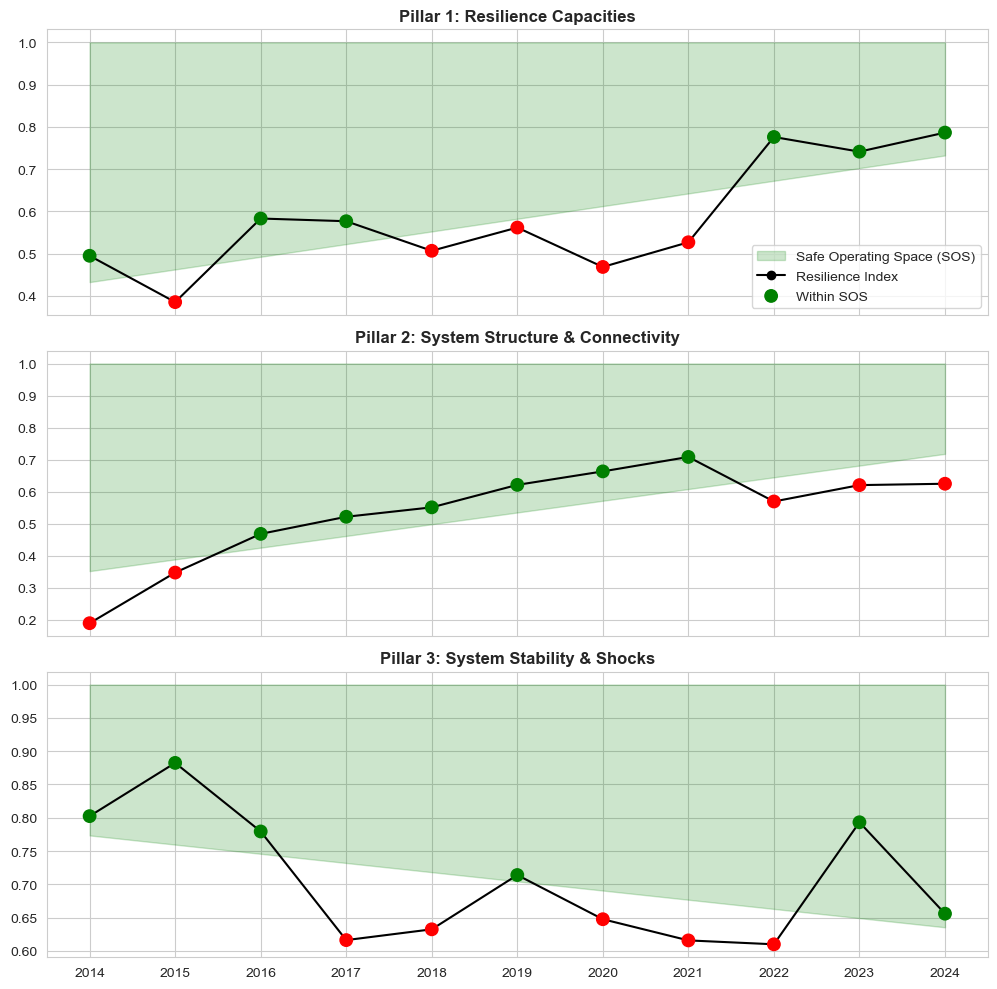

In [ ]:
res = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/Resilience_SOS.csv')
res['date'] = pd.to_datetime(res['Year'].astype(str) + 'Q' + res['Quarter'].astype(str))
#res.set_index(['date'], inplace=True)
#res.drop(columns=['Year', 'Quarter'], inplace=True)
res_ann = res.groupby(['Year','Pillar']).mean()[['Index','SOS','Residual']].reset_index()
res_ann['Index'] = res_ann['Index'] -1
res_ann['SOS'] = res_ann['SOS'] -1

labels = ['Resilience Capacities', 'System Structure & Connectivity', 'System Stability & Shocks']
sns.set_style('whitegrid')
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for p in [1, 2, 3]:
    df_sub = res_ann[res_ann.Pillar == p]
    ax[p-1].fill_between(
        df_sub.Year,
        np.repeat(1, len(df_sub.Year)),
        df_sub['SOS'],
        alpha=0.2,
        label='Safe Operating Space (SOS)',
        color='green'
    )
    # Color markers based on residuals
    colors = np.where(df_sub['Residual'] >= 0, 'green', 'red')
    ax[p-1].plot(
        df_sub.Year,
        df_sub['Index'],
        marker='o',
        label='Resilience Index',
        c='k',
        ls='-'
    )
    # Scatter for colored markers
    ax[p-1].scatter(
        df_sub.Year,
        df_sub['Index'],
        c=colors,
        s=80,
        #edgecolor='k',
        zorder=3,
        label='Within SOS'
    )
    ax[p-1].set_title(f'Pillar {p}: ' + labels[p-1], weight='bold')
    ax[p-1].grid(True)
    ax[p-1].set_xticks(df_sub.Year, [])

ax[p-1].set_xticks(df_sub.Year, df_sub.Year)
ax[0].legend(loc='lower right')
plt.tight_layout()
plt.show()

In [64]:
p1 = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p1.csv')
print(p1.columns.values)

p1_cols = {
    'Year':'Year', 
    'Population':'Population',
    'GRDP per capital (mil dongs)':'Gross Regional Domestic Product (GRDP) per capita',
    'Income per capital (1000 dongs)':'Average monthly income per capita', 
    'Poverty rate':'Poverty rate',
    'Income per capital of quintile 1 (1000 dongs)':'drop',
    '% semi-permanent housing and below':'Share of semi-permanent, less permanent and simple housing',
    'Road length (km)':'drop',
    '% of Agriculture land':'Share of agricultural land',
    'Literacy rate of population aged 15+ ':'Literacy rate of population aged 15+',
    'Rate of trained labor (%)':'Rate of trained labour(with technical/vocational or higher qualification)',
    'Social insurance coverage rate (%)':'Social security coverage',
    'Health insurance coverage rate (%)':'Health insurance coverage',
    'Expenditure on human health, population and family planning / GRDP (%)':'Government expenditure on human health, population and family planning / GRDP',
    'Labour concentration by economic sector':'Labour concentration by economic sector',
    'HHI for Employed population by economic sector':'HHI for employed population by economic sector'}

p1.rename(columns=p1_cols, inplace=True)
p1.drop('Population', axis=1, inplace=True)
#p1.drop(columns=['drop'], inplace=True)
#p1['Average monthly income per capita'] = p1['Average monthly income per capita'] / 1e3
p1.dropna().to_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p1.csv', index=False)

['Year' 'Population' 'Gross Regional Domestic Product (GRDP) per capita'
 'Average monthly income per capita' 'Poverty rate'
 'Share of semi-permanent, less permanent and simple housing'
 'Share of agricultural land' 'Literacy rate of population aged 15+'
 'Rate of trained labour(with technical/vocational or higher qualification)'
 'Social security coverage' 'Health insurance coverage'
 'Government expenditure on human health, population and family planning / GRDP'
 'HHI for employed population by economic sector']


In [63]:
p2 = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p2.csv')
p2_cols = {'Year': 'Year', 
            'Population (1000)': 'Population', 
            'Paddy production (1000 tons)': 'Paddy production',
            'Fishery production (tons)': 'Fishery production', 
            'Number of cows (1000)': 'Number of cows',
            'Number of pigs (1000)': 'Number of pigs', 
            'Number of poultry (1000)': 'Number of poultry', 
            'Meat production': 'Meat production',
            '% of expenditure on non-staple food groups.': 'Share of household food expenditure on non-staple groups',
            'Total markets/supermarkets': 'Total markets/supermarkets', 
            'PCI': 'Provincial Competitiveness Index (PCI)', 
            'Rice HHI for import partners': 'Rice supplier concentration (HHI for import partners)',
            'Meat HHI for import partners': 'Meat supplier concentration (HHI for import partners)',
            'Fish HHI for import partners': 'Fish supplier concentration (HHI for import partners)',
            'Post-harvest lost rate': 'Post-harvest lost rate'}

p2.rename(columns=p2_cols, inplace=True)
p2[['Population', 'Paddy production', 'Number of cows', 'Number of pigs', 'Number of poultry']] = p2[['Population', 'Paddy production', 'Number of cows', 'Number of pigs', 'Number of poultry']] * 1e3
p2.drop('Post-harvest lost rate', axis=1, inplace=True)
p2.dropna().to_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p2.csv', index=False)

In [56]:
p3 = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p3.csv')
P3_cols = { 'Food CPI YoY': 'Food Consumer Price Index (CPI) Year-on-Year change', 
            'Diesel price': 'Diesel price',
            'Diesel price change (same period previous year)': 'Diesel price change',
            'GRDP growth (same period previous year)': 'Gross Regional Domestic Product (GRDP) growth'}

p3.rename(columns=P3_cols, inplace=True)
p3.dropna().to_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p3.csv', index=False)

In [57]:
p3.columns

Index(['Year', 'Quarter', 'Month',
       'Food Consumer Price Index (CPI) Year-on-Year change', 'Diesel price',
       'Diesel price change', 'Gross Regional Domestic Product (GRDP) growth'],
      dtype='object')

In [62]:
# Build resilience indicator reference table from the latest P1/P2/P3 files
resilience_dir = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience"

p1_path = os.path.join(resilience_dir, "resilience_indicators_p1.csv")
p2_path = os.path.join(resilience_dir, "resilience_indicators_p2.csv")
p3_path = os.path.join(resilience_dir, "resilience_indicators_p3.csv")

p1_df = pd.read_csv(p1_path)
p2_df = pd.read_csv(p2_path)
p3_df = pd.read_csv(p3_path)

time_cols = {"Year", "Quarter", "Month"}
p1_indicators = [c for c in p1_df.columns if c not in time_cols]
p2_indicators = [c for c in p2_df.columns if c not in time_cols]
p3_indicators = [c for c in p3_df.columns if c not in time_cols]

all_indicators = sorted(set(p1_indicators + p2_indicators + p3_indicators))

units = {
    "Population": None,
    "Gross Regional Domestic Product (GRDP) per capita": "Million VND",
    "Average monthly income per capita": "VND",
    "Poverty rate": "Percentage",
    "Share of semi-permanent, less permanent and simple housing": "Percentage",
    "Share of agricultural land": "Percentage",
    "Literacy rate of population aged 15+": "Percentage",
    "Rate of trained labour(with technical/vocational or higher qualification)": "Percentage",
    "Social security coverage": "Percentage",
    "Health insurance coverage": "Percentage",
    "Government expenditure on human health, population and family planning / GRDP": "Percentage",
    "HHI for employed population by economic sector": None,
    "Paddy production": "tons",
    "Fishery production": "tons",
    "Number of cows": None,
    "Number of pigs": None,
    "Number of poultry": None,
    "Meat production": "tons",
    "Share of household food expenditure on non-staple groups": "Percentage",
    "Total markets/supermarkets": None,
    "Provincial Competitiveness Index (PCI)": None,
    "Number of policies on Food": None,
    "Rice self-sufficiency rate": "Ratio",
    "Meat self-sufficiency rate": "Ratio",
    "Fish self-sufficiency rate": "Ratio",
    "Rice import rate": "Ratio",
    "Meat import rate": "Ratio",
    "Fish import rate": "Ratio",
    "Rice supplier concentration (HHI for import partners)": None,
    "Meat supplier concentration (HHI for import partners)": None,
    "Fish supplier concentration (HHI for import partners)": None,
    "Post-harvest lost rate": "Percentage",
    "Food Consumer Price Index (CPI) Year-on-Year change": "Percentage",
    "Diesel price": "VND",
    "Diesel price change": "Percentage",
    "Gross Regional Domestic Product (GRDP) growth": "Percentage",
}

components = {
    "Population": None,
    "Gross Regional Domestic Product (GRDP) per capita": "Financial",
    "Average monthly income per capita": "Financial",
    "Poverty rate": "Financial",
    "Share of semi-permanent, less permanent and simple housing": "Physical",
    "Share of agricultural land": "Physical",
    "Literacy rate of population aged 15+": "Human",
    "Rate of trained labour(with technical/vocational or higher qualification)": "Human",
    "Social security coverage": "Human",
    "Health insurance coverage": "Human",
    "Government expenditure on human health, population and family planning / GRDP": "Social",
    "HHI for employed population by economic sector": "Adaptive Capacity",
    "Paddy production": "Supply & Diversification",
    "Fishery production": "Supply & Diversification",
    "Number of cows": "Supply & Diversification",
    "Number of pigs": "Supply & Diversification",
    "Number of poultry": "Supply & Diversification",
    "Meat production": "Supply & Diversification",
    "Share of household food expenditure on non-staple groups": "Supply & Diversification",
    "Total markets/supermarkets": "Supply Chain",
    "Provincial Competitiveness Index (PCI)": "Supply Chain",
    "Number of policies on Food": "Supply Chain",
    "Rice self-sufficiency rate": "Supply & Diversification",
    "Meat self-sufficiency rate": "Supply & Diversification",
    "Fish self-sufficiency rate": "Supply & Diversification",
    "Rice import rate": "Trade & Market Dependence",
    "Meat import rate": "Trade & Market Dependence",
    "Fish import rate": "Trade & Market Dependence",
    "Rice supplier concentration (HHI for import partners)": "Trade & Market Dependence",
    "Meat supplier concentration (HHI for import partners)": "Trade & Market Dependence",
    "Fish supplier concentration (HHI for import partners)": "Trade & Market Dependence",
    "Post-harvest lost rate": "Supply Chain",
    "Food Consumer Price Index (CPI) Year-on-Year change": "Economic",
    "Diesel price": "Economic",
    "Diesel price change": "Economic",
    "Gross Regional Domestic Product (GRDP) growth": "Economic",
}

sources = {
    "Population": "HSO",
    "Gross Regional Domestic Product (GRDP) per capita": "HSO",
    "Average monthly income per capita": "VHLSS, GSO",
    "Poverty rate": "HSO",
    "Share of semi-permanent, less permanent and simple housing": "VHLSS",
    "Share of agricultural land": "GSO",
    "Literacy rate of population aged 15+": "GSO",
    "Rate of trained labour(with technical/vocational or higher qualification)": "GSO",
    "Social security coverage": "HSO",
    "Health insurance coverage": "HSO",
    "Government expenditure on human health, population and family planning / GRDP": "GSO",
    "HHI for employed population by economic sector": "HSO",
    "Paddy production": "GSO, HSO",
    "Fishery production": "GSO, HSO",
    "Number of cows": "GSO, HSO",
    "Number of pigs": "GSO, HSO",
    "Number of poultry": "GSO, HSO",
    "Meat production": "GSO, HSO",
    "Share of household food expenditure on non-staple groups": "VHLSS",
    "Total markets/supermarkets": "GSO",
    "Provincial Competitiveness Index (PCI)": "VCCI",
    "Number of policies on Food": "Desk Review",
    "Rice self-sufficiency rate": "GSO, HSO",
    "Meat self-sufficiency rate": "GSO, HSO",
    "Fish self-sufficiency rate": "GSO, HSO",
    "Rice import rate": "WITS, GSO",
    "Meat import rate": "WITS, GSO",
    "Fish import rate": "WITS, GSO",
    "Rice supplier concentration (HHI for import partners)": "WITS, GSO",
    "Meat supplier concentration (HHI for import partners)": "WITS, GSO",
    "Fish supplier concentration (HHI for import partners)": "WITS, GSO",
    "Post-harvest lost rate": "HSO",
    "Food Consumer Price Index (CPI) Year-on-Year change": "HSO",
    "Diesel price": "Petrolimex",
    "Diesel price change": "Petrolimex",
    "Gross Regional Domestic Product (GRDP) growth": "HSO",
}

pillar_membership = {ind: [] for ind in all_indicators}
for ind in p1_indicators:
    pillar_membership[ind].append(1)
for ind in p2_indicators:
    pillar_membership[ind].append(2)
for ind in p3_indicators:
    pillar_membership[ind].append(3)

records = []
for ind in all_indicators:
    pillars = sorted(set(pillar_membership.get(ind, [])))
    records.append({
        "Indicator": ind,
        "Pillar": ",".join(str(p) for p in pillars) if pillars else None,
        "Component": components.get(ind),
        "Unit": units.get(ind),
        "Source": sources.get(ind),
    })

ref_df = pd.DataFrame(records).sort_values(["Pillar", "Indicator"], na_position="last").reset_index(drop=True)
ref_da = ref_df.copy()

out_path = os.path.join(resilience_dir, "resilience_indicators_ref.csv")
ref_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

ref_df

Saved: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_ref.csv


,Indicator,Pillar,Component,Unit,Source
0,Average monthly income per capita,1,Financial,VND,"VHLSS, GSO"
1,"Government expenditure on human health, popula...",1,Social,Percentage,GSO
2,Gross Regional Domestic Product (GRDP) per capita,1,Financial,Million VND,HSO
3,HHI for employed population by economic sector,1,Adaptive Capacity,None,HSO
4,Health insurance coverage,1,Human,Percentage,HSO
5,Literacy rate of population aged 15+,1,Human,Percentage,GSO
6,Poverty rate,1,Financial,Percentage,HSO
7,Rate of trained labour(with technical/vocation...,1,Human,Percentage,GSO
8,Share of agricultural land,1,Physical,Percentage,GSO
9,"Share of semi-permanent, less permanent and si...",1,Physical,Percentage,VHLSS


In [40]:
ref = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_ref.csv")
ref

,CUFSRiPillar,CUFSRi Component,CUFSRi Indicator,IndicatorUnit,Indicator Data Source,Normalization Direction,Calculation
0,Pillar 1: Resilience Capacities,A1. Financial,Gross Regional Domestic Product (GRDP) per capita,Million dongs (constant price 2020),HSO,+,Hanoi’s GRDP (converted to 2020 prices using I...
1,NaN,NaN,Average monthly income per capita,Million dongs (constant price 2020),"VHLSS, GSO",+,Annual per-capita income from VHLSS and GSO in...
2,NaN,NaN,Poverty rate,% of Hanoi population,HSO,-,From Vietnam Statistical Yearbook
3,NaN,A2. Physical,"Share of semi-permanent, less permanent and si...",% of Hanoi households,VHLSS,-,From Vietnam Statistical Yearbook
4,NaN,NaN,Share of agricultural land,% of Hanoi total natural land area,GSO,+,From Vietnam Statistical Yearbook
5,NaN,A3. Human,Literacy rate of population aged 15+,% of Hanoipopulation 15+,GSO,+,From Vietnam Statistical Yearbook
6,NaN,NaN,Rate of trained labour(with technical/vocation...,% of Hanoiemployed persons,GSO,+,From Vietnam Statistical Yearbook
7,NaN,NaN,Social security coverage,% of Hanoipopulation,HSO,+,Geometric mean of the health- and social-insur...
8,NaN,A4. Social,"Government expenditure on human health, popula...",% of HanoiGRDP,GSO,+,From Vietnam Statistical Yearbook
9,NaN,B. Adaptive Capacity,Labour concentration by economic sector,unitless (0–1),HSO,-,Compute each sector’s employment share in agri...


In [22]:
df_1 = pd.read_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/Resilience indicators_260330_p3.csv')
df_1.rename(columns={'Unnamed: 0': 'Year'}, inplace=True)
df_1.drop('Unnamed: 7', axis=1, inplace=True)
df_1.dropna(how='all',axis=0).set_index('Year').to_csv('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/resilience/resilience_indicators_p3.csv')

In [11]:
path = '/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/'
addis_gdf = gpd.read_file(path+'addis/food_environment/addis_diet_env_mapping.geojson')
hanoi_gdf = gpd.read_file(path+'hanoi/food_environment/hanoi_diet_env_mapping.geojson')

cols_food_env = ['density_healthyout', 'density_unhealthyout', 'density_mixoutlets',
                 'ratio_obesogenic', 'pct_access_healthy', 'ptc_access_unhealthy']

data_labels_food_env = ['Healthy Outlet Density', 'Unhealthy Outlet Density', 'Mixed Outlet Density',
                        'Obesogenic Ratio', 'Percent Access to Healthy Food', 'Percent Access to Unhealthy Food']

print(addis_gdf.columns)
print('================')
print(hanoi_gdf.columns)

rename_dict = {
    'Cnt_density_healthy':'density_healthyout', 
    'cnt_density_Unhealthy':'density_unhealthyout', 
    'density_Mixoutlets':'density_mixoutlets'
}

hanoi_gdf.rename(rename_dict, axis=1, inplace=True)
hanoi_gdf.to_file(path+'hanoi/food_environment/hanoi_diet_env_mapping.geojson')

Index(['id', 'ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1_x', 'ID_2', 'NAME_2_x',
       'ID_3', 'NAME_3', 'CCN_3', 'CCA_3', 'TYPE_3_x', 'ENGTYPE_3_x',
       'NL_NAME_3_x', 'VARNAME_3_x', 'GID_3', 'GID_0', 'COUNTRY', 'GID_1',
       'NAME_1_y', 'NL_NAME_1', 'GID_2', 'NAME_2_y', 'NL_NAME_2',
       'VARNAME_3_y', 'NL_NAME_3_y', 'TYPE_3_y', 'ENGTYPE_3_y', 'CC_3',
       'HASC_3', 'area_km2', 'Count_healthy', 'Count_UnhealthyOutlets',
       'Count_MixOutlets', 'density_healthyout', 'density_unhealthyout',
       'density_mixoutlets', 'ratio_obesogenic', 'classificaction_obesogenic',
       'pop_sum', 'density_pop_healthy', 'density_pop_unhealthy',
       'total_density_pop', 'acc_healthyaccess_pop_healthysum',
       'acc_unhealthyaccess_unhealthy_popsum', 'pct_access_healthy',
       'ptc_access_unhealthy', 'classification_access_pop', 'geometry'],
      dtype='object')
Index(['ma_xa', 'ten_xa', 'sap_nhap', 'tru_so', 'loai', 'cap', 'stt',
       'dtich_km2', 'dan_so', 'matdo_km2', 'ma_tinh

In [10]:
path = '/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data'
gdf_resilience = gpd.read_file(os.path.join(path, 'hanoi_resilience_district_annual_stats.geojson')).to_crs("EPSG:4326")
gdf_resilience['geometry'] = gdf_resilience['geometry'].buffer(0)
gdf_resilience = gdf_resilience[gdf_resilience['geometry'].is_valid & ~gdf_resilience['geometry'].is_empty]
resilience_years = sorted(gdf_resilience['year'].dropna().unique().astype(int).tolist())
resilience_geojson_base = json.loads(gdf_resilience[['geometry', 'shapeName']].drop_duplicates('shapeName').set_index('shapeName').to_json())

In [26]:
gdf_resilience['stress_med'].describe()

count    8726.000000
mean        0.165823
std         0.091445
min         0.001337
25%         0.096145
50%         0.154073
75%         0.218713
max         0.575504
Name: stress_med, dtype: float64

In [17]:
homepath = '/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development'
path     = os.path.join(homepath, "assets", "data")
out_path = os.path.join(path, "precomputed")
os.makedirs(out_path, exist_ok=True)

print("Loading resilience GDF...")
gdf = gpd.read_file(os.path.join(path, "hanoi_resilience_district_annual_stats.geojson")).to_crs("EPSG:4326")
gdf["geometry"] = gdf["geometry"].buffer(0)
gdf = gdf[gdf["geometry"].is_valid & ~gdf["geometry"].is_empty]

# ── 1. Base GeoJSON (all unique districts, geometry + shapeName as property) ──
print("Saving base districts GeoJSON...")
districts_unique = (
    gdf[["shapeName", "geometry"]]
    .drop_duplicates("shapeName")
    .copy()
    .reset_index(drop=True)
)
with open(os.path.join(out_path, "resilience_districts_base.geojson"), "w") as f:
    f.write(districts_unique.to_json())
print(f"  → {len(districts_unique)} unique districts saved")

# ── 2. Annual lookup: one lightweight CSV per year ────────────────────────────
print("Saving per-year CSVs...")
years = sorted(gdf["year"].dropna().unique().astype(int).tolist())
annual_dir = os.path.join(out_path, "resilience_annual")
os.makedirs(annual_dir, exist_ok=True)

for yr in years:
    grp = gdf[gdf["year"] == yr][["shapeName", "stress_med", "resistance_med"]].reset_index(drop=True)
    grp.to_csv(os.path.join(annual_dir, f"{yr}.csv"), index=False)

print(f"  → {len(years)} year CSVs saved  ({min(years)}–{max(years)})")

# ── 3. Per-year drought GeoJSONs (only districts with non-NaN values) ─────────
print("Saving per-year drought GeoJSONs...")
drought_dir = os.path.join(out_path, "resilience_drought_geojsons")
os.makedirs(drought_dir, exist_ok=True)

for yr in years:
    grp = gdf[gdf["year"] == yr][["shapeName", "stress_med", "resistance_med"]].reset_index(drop=True)

    # Stress drought districts
    stress_names = grp[grp["stress_med"].notna()]["shapeName"].tolist()
    stress_gdf   = districts_unique[districts_unique["shapeName"].isin(stress_names)]
    with open(os.path.join(drought_dir, f"{yr}_stress.geojson"), "w") as f:
        f.write(stress_gdf.to_json())

    # Resistance drought districts
    resist_names = grp[grp["resistance_med"].notna()]["shapeName"].tolist()
    resist_gdf   = districts_unique[districts_unique["shapeName"].isin(resist_names)]
    with open(os.path.join(drought_dir, f"{yr}_resistance.geojson"), "w") as f:
        f.write(resist_gdf.to_json())

print(f"  → {len(years) * 2} drought GeoJSONs saved")

# ── 4. VCI stats: pre-serialise base GeoJSON + z-value lookup ─────────────────
print("Loading VCI stats GDF...")
gdf_vci = gpd.read_file(os.path.join(path, "vietnam_severe_drought_pct_2000_2024.geojson")).to_crs("EPSG:4326")
gdf_vci["geometry"] = gdf_vci["geometry"].buffer(0)
gdf_vci = gdf_vci[gdf_vci["geometry"].is_valid & ~gdf_vci["geometry"].is_empty]

date_cols = gdf_vci.columns[5:-1].values
for c in date_cols:
    gdf_vci[c] = pd.to_numeric(gdf_vci[c], errors="coerce")

# Save base GeoJSON (geometry only)
print("Saving VCI base GeoJSON...")
with open(os.path.join(out_path, "vci_base.geojson"), "w") as f:
    f.write(gdf_vci[["geometry"]].to_json())

# Save z-values as a single wide CSV (rows = districts, cols = dates)
print("Saving VCI z-values CSV...")
vci_z = gdf_vci[list(date_cols)].copy()
vci_z.to_csv(os.path.join(out_path, "vci_z_values.csv"), index=True)

# Save dates list
with open(os.path.join(out_path, "vci_dates.json"), "w") as f:
    json.dump(date_cols.tolist(), f)

print(f"  → {len(date_cols)} VCI dates saved")

# ── 5. Save metadata (years list, date count etc.) ────────────────────────────
meta = {
    "resilience_years":   [int(y) for y in years],
    "vci_date_count":     int(len(date_cols)),
}
with open(os.path.join(out_path, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("\n✅  All precomputed assets saved to:", out_path)
print("   Files created:")
for root, dirs, files in os.walk(out_path):
    for fname in files:
        rel = os.path.relpath(os.path.join(root, fname), out_path)
        print(f"     {rel}")

Loading resilience GDF...
Saving base districts GeoJSON...
  → 678 unique districts saved
Saving per-year CSVs...
  → 25 year CSVs saved  (2000–2024)
Saving per-year drought GeoJSONs...
  → 50 drought GeoJSONs saved
Loading VCI stats GDF...
Saving VCI base GeoJSON...
Saving VCI z-values CSV...
  → 299 VCI dates saved

✅  All precomputed assets saved to: /Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/precomputed
   Files created:
     resilience_districts_base.geojson
     vci_dates.json
     vci_z_values.csv
     vci_base.geojson
     meta.json
     resilience_annual/2008.csv
     resilience_annual/2020.csv
     resilience_annual/2021.csv
     resilience_annual/2009.csv
     resilience_annual/2023.csv
     resilience_annual/2022.csv
     resilience_annual/2019.csv
     resilience_annual/2018.csv
     resilience_annual/2024.csv
     resilience_annual/2001.csv
     resilience_annual/2015.csv
     resilience_annual/2014.csv
     resi

In [34]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi_policy_database.csv")
df.drop(['ď»żRecord Id', 'Date of original text', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Year.1', 'Document URL'], axis=1, inplace=True)
df.rename(columns={'Year': 'Year Enacted',
                   'Date of original text.1': 'Date of Original Text',
                   'Record URL': 'Document Link'}, inplace=True)
df.dropna(axis=1, how='all', inplace=True)  # Drop columns that are completely empty
df = df[['Title', 'Type of text', 'Primary subjects', 'Domain', 
         'Keywords', 'Year Enacted', 'Document Link', 
         'Available website', 'Language of document', 'Country/Territory',
         'Repealed', 'Abstract', 'Date of Original Text']]

df.to_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi_policy_database_cleaned.csv", index=False)

In [33]:
df['Available website'].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, 'https://thuvienphapluat.vn/', nan, nan, nan, nan,
       'https://thuvienphapluat.vn', nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, 'www.vietnamlawmagazine.vn/',
       'www.vietnamlawmagazine.vn/', 'www.vietnamlawmagazine.vn/',
       'www.vietnamlawmagazine.vn', 'www.vietnamlawmagazine.vn',
       'www.luatkhaiphong.com', 'www.vietnamlawmagazine.vn',
       'www.vietnamlawmagazine.vn', 'www.vietnamlawmagazine.vn',
       'www.vietnamlawmagazine.vn', 'www.vietnamlawmagazine.vn',
       'www.vietnamlawmagazine.vn', 'w

In [23]:
df

,Document Link,Title,Original title,Date of original text,Year Enacted,Last amended date,Available website,Language of document,Country/Territory,Regional organizations,Territorial subdivision,Type of text,Repealed,Abstract,Primary subjects,Domain,Keywords,Date of Original Text
0,http://www.fao.org/faolex/results/details/en/c...,Decision No. 2629/1997/BYT-QD issuing the list...,NaN,35777,1997,NaN,NaN,English,Viet Nam,NaN,NaN,Regulation,NaN,The Decision contains a list of food commoditi...,Food & nutrition,Food & nutrition,agricultural commodities; registration; milk/d...,13
1,http://www.fao.org/faolex/results/details/en/c...,Decision No. 980/1997/QD-TTg approving the sal...,NaN,35752,1997,NaN,NaN,English,Viet Nam,NaN,NaN,Regulation,Y,Pursuant to the Law on the Organization of the...,Food & nutrition,Food & nutrition,agricultural development; subsidy/incentive; c...,18
2,http://www.fao.org/faolex/results/details/en/c...,Ordinance on the Protection of Consumer Intere...,NaN,05/08/1999,1999,NaN,NaN,English,Viet Nam,NaN,NaN,Regulation,Y,This Ordinance sets out rights and responsibil...,Food & nutrition,Food & nutrition,food safety and quality; hygiene/sanitary proc...,05/08/1999
3,http://www.fao.org/faolex/results/details/en/c...,Regulation on the labeling of goods to be circ...,NaN,36402,1999,NaN,NaN,English,Viet Nam,NaN,NaN,Regulation,Y,This Regulation prescribes rules for the label...,Food & nutrition,Food & nutrition,food safety and quality; agricultural commodit...,30
4,http://www.fao.org/faolex/results/details/en/c...,Regulation on the State Control of import-expo...,NaN,36333,1999,NaN,NaN,English,Viet Nam,NaN,NaN,Regulation,NaN,This Regulation prescribes methods and procedu...,Food & nutrition,Food & nutrition,food safety and quality; international trade; ...,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,http://www.fao.org/faolex/results/details/en/c...,Decree No. 118/2020/ND-CP on amendments to Dec...,NaN,10/02/2020,2020,NaN,https://thuvienphapluat.vn/,English,Viet Nam,NaN,NaN,Regulation,NaN,This Decree amends a number of articles of the...,Livestock; Cultivated plants,Livestock; Food & nutrition; Cultivated plants,genetically modified organism (GMO); research;...,10/02/2020
145,http://www.fao.org/faolex/results/details/en/c...,Circular on Traceability of Food-related Produ...,NaN,43707,2019,NaN,https://thuvienphapluat.vn,English,Viet Nam,NaN,NaN,Regulation,NaN,This Circular prescribes principles and cases ...,Food & nutrition,Food & nutrition,food safety and quality; traceability; Codex A...,30
146,http://www.fao.org/faolex/results/details/en/c...,Resolution on Ensuring National Food Security ...,NGHỊ QUYẾT VỀ BẢO ĐẢM AN NINH LƯƠNG THỰC QUỐC ...,44280,2021,NaN,https://thuvienphapluat.vn/,Vietnamese,Viet Nam,NaN,NaN,Policy,NaN,The overall goals of this policy document are:...,Food & nutrition,Agricultural & rural dev.; Livestock; Food & n...,food security; internal trade; international c...,25
147,http://www.fao.org/faolex/results/details/en/c...,Decision 1294/QD-BYT 2022 issuing the Action ...,NaN,44700,2022,NaN,https://thuvienphapluat.vn/,English,Viet Nam,NaN,NaN,"Regulation, Policy",NaN,This Action Plan to Implement the National Nut...,Food & nutrition,Food & nutrition,nutrition; policy/planning; capacity building;...,19


In [27]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_policy_database.csv").dropna(axis=0,how='all').dropna(axis=1,how='all')
df.replace(np.nan, '--', inplace=True)
df.drop('Name of Researcher Compiled data',axis=1,inplace=True)
df.to_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_policy_database.csv")

In [ ]:
homepath = os.getcwd()
path = homepath + "/assets/data/"
df_sh_hanoi = pd.read_csv(path+"/hanoi_stakeholders.csv").dropna(how='any').astype(str)
df_sh_hanoi

,Organisation Name,Stakeholder catagorization,Area of Activity in the food system
0,ASSET : Agroecological and Safe food System Tr...,International community,Service provision
1,Agriculture and Life Journal,Media,Sociocultural element
2,Agriculture and Rural Development Bank (Agribank),Private sector,Finance
3,Agriculture Journal,Media,Sociocultural element
4,Alliance Bioversity CIAT,International community,Service provision
...,...,...,...
109,World Health Organization (WHO),International community,Institutional elements
110,World Vision International Vietnam,International community,Service provision
111,World Wide Fund For Nature (WWF),International community,Service provision
112,Sustainable Food Systems Ireland in Vietnam,International community,Service provision


In [7]:
df_sh.columns

Index(['Organisation Name', 'Primary sector ', 'Main Focus area* ',
       'Focus area 2 (if available)', 'Focus area 3 (if available)',
       'Area of Activity (Food Systems Value Chain)', 'Scale of Activity',
       'Description', 'Website', 'Name #1', 'Research domain', 'Role  #1',
       'Email  #1', 'Telephone  #1', 'Name #2', 'Role  #2', 'Email  #2',
       'Telephone  #2', 'Name #3', 'Role  #3', 'Email  #3', 'Telephone  #3',
       'Name #4', 'Role  #4', 'Email  #4', 'Telephone  #4', 'Name #5',
       'Role  #5', 'Email  #5', 'Telephone  #5', 'Workshop Attendee?',
       'Contacted for EFS Activity?', 'Collaboration Details',
       'Person who sourced the contact', 'Contact checked (Y/N)'],
      dtype='object')

In [16]:
df_sh = pd.read_csv(path+"/addis_stakeholders.csv")
df_sh_clip = df_sh[['Organisation Name', 'Primary sector ', 'Area of Activity (Food Systems Value Chain)', 'Scale of Activity', 'Website', 'Description']]
df_sh_clip = df_sh_clip.drop_duplicates()
df_sh_clip = df_sh_clip.set_index('Organisation Name').dropna(how='all')
df_sh_clip = df_sh_clip[~df_sh_clip.apply(lambda x: len(set(x)) == 1, axis=1)]
df_sh_clip = df_sh_clip.replace('Natiional', 'National', regex=False)
df_sh_clip.replace(np.nan, '--', inplace=True)
df_sh_clip

,Primary sector,Area of Activity (Food Systems Value Chain),Scale of Activity,Website,Description
Organisation Name,,,,,
Action for Development,Civil Society,Capacity Building and Aid,National,https://www.afdethiopia.org/contact,Food security and sustinable livelihoods
World Bank,International Community,Capacity Building and Aid,International,https://www.worldbank.org/en/country/ethiopia,"Focuses on delivery of basic services, food se..."
CARE Ethiopia,Civil Society,Capacity Building and Aid,National (NGO),https://www.care.org/our-work/where-we-work/et...,"Works on food securtiy, health, education, cli..."
Mercy Corps,Civil Society,Capacity Building and Aid,National (NGO),https://www.mercycorps.org/where-we-work/ethiopia,"Works on food securtiy, health, and climate"
IFAD,Civil Society,Capacity Building and Aid,National (NGO),https://www.ifad.org/en/w/countries/ethiopia,By colaborating with the government of Ethiopi...
...,...,...,...,...,...
Melka Ethiopia,Civil Society,Capacity building and aid,National NGO,https://melcaethiopia.org/,--
Ethiopian Sustainable Food System and Agroecology Consortium,Civil Society,Capacity building and aid,National NGO,https://esfsac-ethiopia.org/about/,--
Addis Ababa Abattoirs Enterprise,Private Sector,Trade,National,--,--


In [ ]:
for col in df_sh_clip.columns:
    print(col,
df_sh_clip[col].astype(str).str.len().max())

Primary sector  42
Area of Activity (Food Systems Value Chain) 68
Scale of Activity 25
Website 85
Description 510


In [17]:
df_sh_clip.to_csv(path+"/addis_stakeholders_cleaned.csv")

In [9]:
df_nutr = pd.read_csv("/home/jemima/Data/EcoFoodSystems_Dashboard_Development/assets/data/addis_nutrition_outcomes_cleaned.csv")
df_nutr.head(10)

,Cat,Age groups,Outcomes,Reg,Value
0,Percent Distribution of Stunting Among Childre...,CHILDREN,Stunting,Addis Ababa,13.9
1,Percent Distribution of Stunting Among Childre...,CHILDREN,Stunting,National,40.9
2,Percent Distribution of Stunting Among Childre...,CHILDREN,Wasting (%),Addis Ababa,3.8
3,Percent Distribution of Stunting Among Childre...,CHILDREN,Wasting (%),National,11.2
4,Percent Distribution of Stunting Among Childre...,CHILDREN,Underweight (%),Addis Ababa,5.5
5,Percent Distribution of Stunting Among Childre...,CHILDREN,Underweight (%),National,23.3


In [16]:
df_mpi = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/Hanoi_districts_MPI_long.csv")
df_mpi.head(10)

,Dist_Name,Variable,Value
0,Ba Dinh,Cooking fuel,51.52
1,Ba Vi,Cooking fuel,91.19
2,Bac Tu Liem,Cooking fuel,66.65
3,Cau Giay,Cooking fuel,39.46
4,Chuong My,Cooking fuel,93.99
5,Dan Phuong,Cooking fuel,90.90
6,Dong Anh,Cooking fuel,91.06
7,Dong Da,Cooking fuel,49.63
8,Gia Lam,Cooking fuel,83.55
9,Ha Dong,Cooking fuel,56.21


In [30]:
gdf = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis/mpi/addis_districts_MPI.geojson")
gdf.rename(columns={'MPI': 'Multidimensional Poverty Index'}, inplace=True)
gdf#.to_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis/mpi/addis_adm3_mpi.geojson")

,id,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,ID_3,NAME_3,...,Mild food insecure,Moderat to sever food insecure,Drinking water,Housing,Sanitation,Electricity,Cooking fuel,Assets,Dist_Name,geometry
0,eth_adm3.1,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,1,Addis Ketema,...,25.8,38.2,9.8,79.0,85.7,0.0,28.0,44.2,Addis Ketema,"MULTIPOLYGON (((38.71598 9.05325, 38.72404 9.0..."
1,eth_adm3.2,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,2,Akaki Kality,...,33.1,48.0,4.5,52.5,69.6,0.0,21.7,27.7,Akaki Kality,"MULTIPOLYGON (((38.74359 8.90259, 38.74577 8.9..."
2,eth_adm3.3,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,3,Arada,...,24.2,21.1,11.1,95.4,84.2,0.0,0.0,0.3,Arada,"MULTIPOLYGON (((38.76545 9.02205, 38.75837 9.0..."
3,eth_adm3.4,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,4,Bole,...,0.6,14.7,3.6,38.9,80.6,0.0,15.5,35.3,Bole,"MULTIPOLYGON (((38.77277 8.95171, 38.77505 8.9..."
4,eth_adm3.5,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,5,Gulele,...,28.0,30.7,5.5,89.8,90.3,0.0,39.6,44.4,Gulele,"MULTIPOLYGON (((38.79131 9.07768, 38.78229 9.0..."
5,eth_adm3.6,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,6,Kirkos,...,12.5,24.9,6.7,40.3,60.7,0.0,13.1,24.1,Kirkos,"MULTIPOLYGON (((38.7642 8.98005, 38.75804 8.98..."
6,eth_adm3.7,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,7,Kolfe Keraniyo,...,13.8,13.8,21.8,35.9,53.8,0.0,19.3,22.3,Kolfe Keraniyo,"MULTIPOLYGON (((38.71638 9.02076, 38.71041 9.0..."
7,eth_adm3.8,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,8,Lideta,...,44.8,10.5,4.7,93.1,73.3,0.0,11.0,41.5,Lideta,"MULTIPOLYGON (((38.73779 8.99642, 38.73092 8.9..."
8,eth_adm3.9,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,9,Nifas Silk Lafto,...,23.1,16.6,8.2,49.5,56.6,0.0,20.7,23.3,Nifas Silk Lafto,"MULTIPOLYGON (((38.71505 8.99294, 38.71918 8.9..."
9,eth_adm3.10,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,10,Yeka,...,13.9,36.1,36.3,89.2,68.5,6.3,34.6,48.8,Yeka,"MULTIPOLYGON (((38.76545 9.02205, 38.76933 9.0..."


In [36]:
gdf = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_districts_MPI.geojson")
gdf.rename(columns={'Multidimensional Poverty Index': 'Multidimensional Poverty Index', 'Cooking fuel ': 'Cooking fuel', 'Housing ': 'Housing', 'Assets': 'Assets',
       'Drinking water ': 'Drinking water', 'Sanitation ': 'Sanitation', 'Electricity ': 'Electricity'
       }, inplace=True)
gdf.to_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/hanoi/mpi/hanoi_districts_MPI.geojson")

In [38]:
gdf.columns

Index(['Dist_Name', 'Dist_name', 'Dis_code', 'MPI_LS',
       'Multidimensional Poverty Index', 'Cooking fuel', 'Housing', 'Assets',
       'Drinking water', 'Sanitation', 'Electricity', 'depri_cata', 'id',
       'Com_cod', 'Dist_cod', 'geometry'],
      dtype='object')

In [7]:
gdf_mpi = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_adm3_mpi.geojson")
gdf_mpi.columns #.plot('MPI', cmap='OrRd', legend=True)

Index(['id', 'ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2',
       'ID_3', 'NAME_3', 'CCN_3', 'CCA_3', 'TYPE_3', 'ENGTYPE_3', 'NL_NAME_3',
       'VARNAME_3', 'Sub City', 'MPI', 'Food secure', 'Mild food insecure',
       'Moderat to sever food insecure', 'Drinking water', 'Housing',
       'Sanitation', 'Electricity', 'Cooking fuel', 'Assets', 'Dist_Name',
       'geometry'],
      dtype='object')

In [26]:
df_foodsec = pd.read_csv("/home/jemima/Data/EcoFoodSystems_Dashboard_Development/assets/data/addis_foodsecurity.csv")
df_foodsec.replace({'Moderat to sever food insecure':'Moderate-Severe Food Insecurity',
                    'Food secure':'Secure',
                    'Mild food insecure':'Mild Food Insecurity  '}, inplace=True)
df_foodsec.head(10)

,Sub City,Food security status,Percentage
0,Addis Ketema,Secure,36.0
1,Addis Ketema,Mild Food Insecurity,25.8
2,Addis Ketema,Moderate-Severe Food Insecurity,38.2
3,Akaki Kality,Secure,18.9
4,Akaki Kality,Mild Food Insecurity,33.1
5,Akaki Kality,Moderate-Severe Food Insecurity,48.0
6,Arada,Secure,54.7
7,Arada,Mild Food Insecurity,24.2
8,Arada,Moderate-Severe Food Insecurity,21.1
9,Bole,Secure,84.7


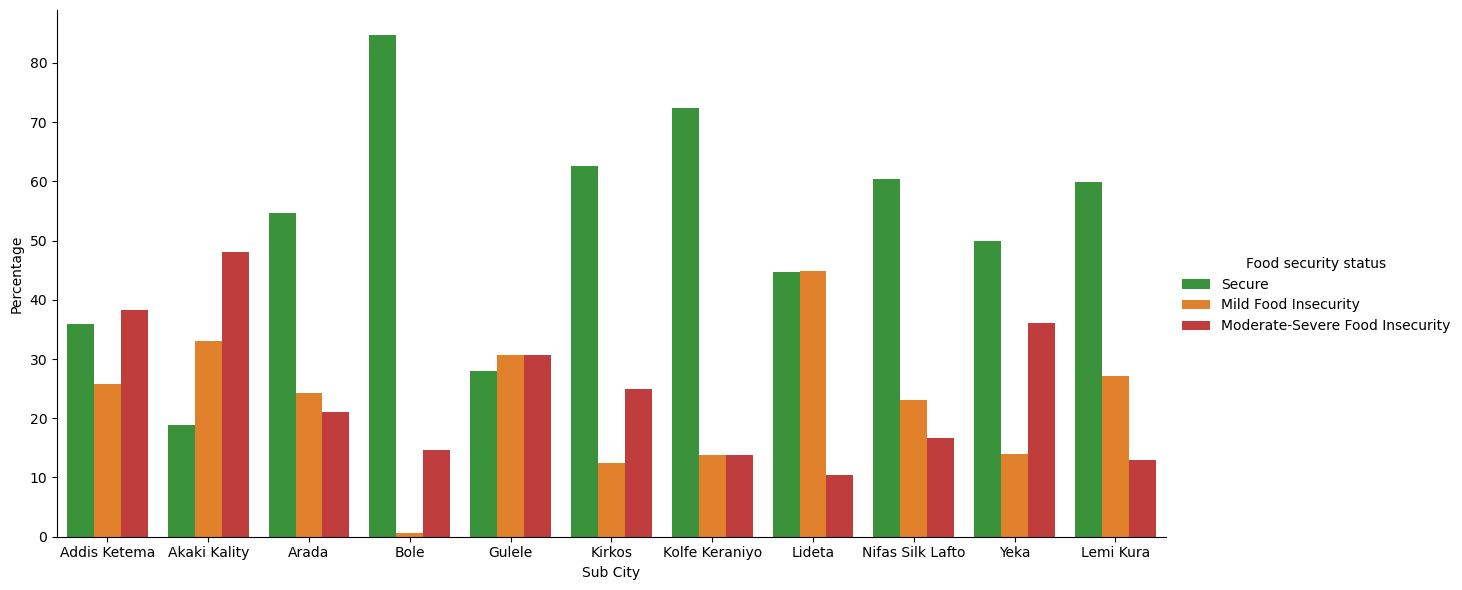

In [27]:
sns.catplot(df_foodsec, kind='bar', x='Sub City', y='Percentage', hue='Food security status', 
            palette=['#2ca02c', '#ff7f0e', '#d62728'],
            height=6, aspect=12/6)

In [95]:
df_foodsec_long = df_foodsec.pivot(index='Sub City', columns='Food security status', values='Percentage')
geos = gdf_mpi[['NAME_3', 'geometry']]
geoseries = gpd.GeoDataFrame(gpd.GeoSeries(geos.set_index('NAME_3')['geometry']).to_crs('EPSG:4326').representative_point())
gdf_foodsec = geoseries.merge(df_foodsec_long, left_on='NAME_3', right_index=True).set_geometry(0)
gdf_foodsec.rename(columns={0: 'geometry'}, inplace=True)
gdf_foodsec = gdf_foodsec[['Secure', 'Mild Food Insecurity  ', 'Moderate-Severe Food Insecurity', 'geometry']]
gdf_foodsec.head(5)

,Secure,Mild Food Insecurity,Moderate-Severe Food Insecurity,geometry
NAME_3,,,,
Addis Ketema,36.0,25.8,38.2,POINT (38.72656 9.03828)
Akaki Kality,18.9,33.1,48.0,POINT (38.80992 8.89919)
Arada,54.7,24.2,21.1,POINT (38.75797 9.03537)
Bole,84.7,0.6,14.7,POINT (38.83602 8.98208)
Gulele,28.0,30.7,30.7,POINT (38.73853 9.07104)


In [96]:
gdf_foodsec.to_file("/home/jemima/Data/EcoFoodSystems_Dashboard_Development/assets/data/addis_food_security.geojson")

<Axes: >

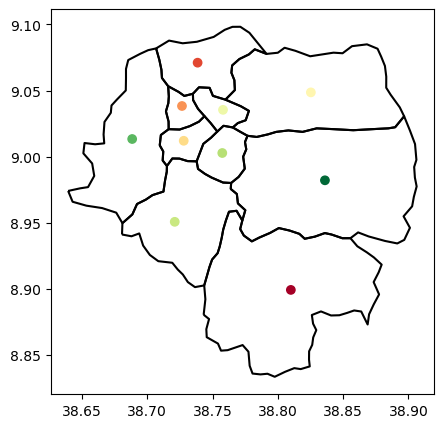

In [89]:
fig,ax = plt.subplots(1,1,figsize=(5,5))
gdf_foodsec.plot('Secure', ax=ax, cmap='RdYlGn')
geos.boundary.plot(ax=ax, color='black')

In [ ]:
def create_pie_chart_icon(values, colors, size=40):
    """
    Create a pie chart as a base64 encoded image for use as a Leaflet marker icon.
    
    Parameters:
    - values: list of values for pie slices
    - colors: list of colors for each slice
    - size: size of the icon in pixels
    """
    fig, ax = plt.subplots(figsize=(size/100, size/100), dpi=100)
    ax.pie(values, colors=colors, startangle=90)
    ax.axis('equal')
    
    # Remove margins
    plt.tight_layout(pad=0)
    
    # Save to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', transparent=True, bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    plt.close()
    
    # Encode to base64
    img_base64 = base64.b64encode(buf.read()).decode()
    return f"data:image/png;base64,{img_base64}"

In [ ]:
import dash_leaflet as dl
from dash import Dash, html
import dash_bootstrap_components as dbc
import matplotlib.pyplot as plt
import io
import base64
import json

# Create a simple Dash app with Leaflet map
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# Create pie chart markers for food security data with tooltips
marker_lst = []
for i in range(gdf_foodsec.shape[0]):
    # Get the subcity name and food security percentages
    subcity_name = gdf_foodsec.index[i]
    secure = gdf_foodsec.iloc[i]['Secure']
    mild = gdf_foodsec.iloc[i]['Mild Food Insecurity  ']
    severe = gdf_foodsec.iloc[i]['Moderate-Severe Food Insecurity']
    
    # Create tooltip content - using simpler text format
    tooltip_content = f"{subcity_name} - \nSecure: {secure:.1f}%\nMild: {mild:.1f}%\nSevere: {severe:.1f}%"
    
    marker = dl.Marker(
        position=[float(x) for x in str(gdf_foodsec.iloc[i].values[-1]).split('POINT (')[1].strip(')').replace(' ', ', ').split(',')][::-1], 
        icon = {
            "iconUrl": create_pie_chart_icon(gdf_foodsec.iloc[i].values[:3], ['#2ca02c', '#ff7f0e', '#d62728'], size=30),
            "iconSize": [30, 30],
            "iconAnchor": [15, 15]  # Center the icon
        },
        children=[
            dl.Tooltip(tooltip_content)
        ]
    )
    marker_lst.append(marker)

# Convert GeoDataFrame boundaries to GeoJSON format
boundaries_geojson = json.loads(geos.to_json())

# Define the layout with different basemap and boundaries
app.layout = html.Div([
    html.H3("Addis Ababa Food Security Dashboard", style={"textAlign": "center"}),
    dl.Map(
        [
            # CartoDB Positron (light clean basemap)
            dl.TileLayer(
                url="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
                attribution='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>'
            ),
            
            # Add GeoJSON boundaries layer
            dl.GeoJSON(
                data=boundaries_geojson,
                style={
                    'color': 'black',
                    'weight': 1,
                    'fillOpacity': 0,  # Transparent fill
                },
                id='boundaries-layer'
            ),
            
            # Add pie chart markers on top
            dl.LayerGroup(marker_lst, id='markers-layer')
        ],
        center=[8.991626, 38.763706],
        zoom=11,
        style={"width": "100%", "height": "90vh"},
    )
])

# Run the app in Jupyter mode
# This will start the server on port 8050 (or next available)
# Access it at http://localhost:8050 in your browser
if __name__ == '__main__':
    app.run(debug=True, jupyter_mode='external', port=8050)

Dash app running on http://127.0.0.1:8050/


In [ ]:
import plotly.express as px

outlets = os.listdir('/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/jsons_addis/')
cats = [str(o.split('_')[0]) for o in outlets]
names = [
    o.split('_')[1] if len(o.split('_')) < 4
    else f"{o.split('_')[1]} {o.split('_')[2]}"
    for o in outlets
]

['shop', 'amenity', 'shop', 'shop', 'shop', 'shop', 'amenity', 'shop', 'shop', 'amenity', 'shop', 'shop', 'amenity', 'shop', 'shop', 'amenity', 'amenity', 'amenity', 'shop', 'shop', 'amenity', 'amenity', 'shop', 'amenity', 'shop']


In [14]:
pip install dash_leaflet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.2/810.2 kB 9.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [dash_leaflet] [dash-extensions]]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
import geopandas as gpd
import dash
from dash import html, dcc
import dash_leaflet as dl
from dash.dependencies import Input, Output

app = dash.Dash(__name__)

dirpath = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/jsons_addis/"
geojson_files = sorted(os.listdir(dirpath))

# Define a simple color palette
colors = ["blue", "red", "green", "orange", "purple", "brown", "pink", "cyan"]

app.layout = html.Div([
    html.Div([
        dcc.Dropdown(
            id="layer-select",
            options=[{"label": f.split('_')[1] if len(f.split('_')) < 4 else f"{f.split('_')[1]} {f.split('_')[2]}", 
                      "value": f} for f in geojson_files],
            multi=True,
            placeholder="Select outlet layers to display")],
        style={
            'margin': '10px 50px',
            'zIndex': '1000',
            'justifyContent': 'end',
            'alignItems': 'center',
            'textAlign': 'center'
        }
    ),
    
    dl.Map(center=[9.1, 38.7], zoom=10, children=[
         dl.TileLayer(
                url="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
                attribution='&copy; OpenStreetMap contributors &copy; CARTO'
            ),
        dl.LayerGroup(id="geojson-layers")
    ], style={'width': '100%', 'height': '600px'})
])


@app.callback(
    Output("geojson-layers", "children"),
    Input("layer-select", "value")
)
def update_layers(selected):
    if not selected:
        return []

    layers = []

    for i, filename in enumerate(selected):
        f = gpd.read_file(dirpath + filename).to_crs('EPSG:4326')
        g = json.loads(f.to_json())
        color = colors[i % len(colors)]  # Cycle through palette if more layers than colors

        layers.append(
            dl.GeoJSON(
                data=g,
                zoomToBounds=True,
                cluster=True,
                zoomToBoundsOnClick=True,
                superClusterOptions=dict(radius=100),
                id=filename.split('_')[1] if len(filename.split('_')) < 4 else f"{filename.split('_')[1]} {filename.split('_')[2]}",
                options=dict(style=dict(color=color, weight=2, opacity=0.5, fillOpacity=0.2),
            )
        ))

    return layers

app.run(debug=True)

In [ ]:
gpd = gpd.read_csv()

In [45]:
filename = outlets[0]
f = gpd.read_file(dirpath+filename).to_crs('EPSG:4326')
g = json.loads(f.to_json())
name = filename.split('_')[1] if len(filename.split('_')) < 4 else f"{filename.split('_')[1]} {filename.split('_')[2]}"
name

'convenience'

In [24]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_nutrition_outcomes_cleaned.csv")
print(*df['Cat'][12:18])

Percent Distribution of Anthropometric Status of WRA (15-49 Years) Body Mass Index (BMI) Percent Distribution of Anthropometric Status of WRA (15-49 Years) Body Mass Index (BMI) Percent Distribution of Anthropometric Status of WRA (15-49 Years) Body Mass Index (BMI) Percent Distribution of Anthropometric Status of WRA (15-49 Years) Body Mass Index (BMI) Percent Distribution of Anthropometric Status of Adolescent Girls (10-19 Years)  Percent Distribution of Anthropometric Status of Adolescent Girls (10-19 Years) 


In [3]:
gdf = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_diet_env_mapping.geojson")
gdf

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,...,pop_sum,density_pop_healthy,density_pop_unhealthy,total_density_pop,acc_healthyaccess_pop_healthysum,acc_unhealthyaccess_unhealthy_popsum,pct_access_healthy,ptc_access_unhealthy,classification_access_pop,geometry
0,ETH.1.1.1_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,AddisKetema,...,140444.615778,0.014240,0.163766,0.178006,5805.536378,97089.748271,4.134,69.130,Low Access,"MULTIPOLYGON (((470876.504 1000114.243, 470887..."
1,ETH.1.1.2_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Akaki-Kalit,...,484063.490809,0.006198,0.051646,0.057844,21893.776116,104129.843980,4.523,21.512,Low Access,"MULTIPOLYGON (((475024.176 989519.976, 474836...."
2,ETH.1.1.3_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Arada,...,155281.791363,0.019320,0.444353,0.463673,28127.141331,138080.643343,18.114,88.923,Low Access,"MULTIPOLYGON (((471842.317 998245.112, 470887...."
3,ETH.1.1.4_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Bole,...,802868.140773,0.034875,0.252844,0.287718,218152.580956,402970.753994,27.172,50.191,Middle Acc,"MULTIPOLYGON (((484125.724 988033.917, 483444...."
4,ETH.1.1.5_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Gulele,...,291495.887090,0.006861,0.089195,0.096056,29943.483639,148264.912413,10.272,50.863,Low Access,"MULTIPOLYGON (((470876.504 1000114.243, 470140..."
5,ETH.1.1.6_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Kirkos,...,239721.892516,0.050058,0.442179,0.492237,68628.351719,234610.767325,28.628,97.868,Middle Acc,"MULTIPOLYGON (((472918.528 996961.894, 473446...."
6,ETH.1.1.7_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Kolfe-Keran,...,793869.896166,0.010077,0.051646,0.061723,65862.308874,261015.685452,8.296,32.879,Low Access,"MULTIPOLYGON (((468788.888 1000757.057, 468798..."
7,ETH.1.1.8_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Lideta,...,161852.194137,0.006178,0.086499,0.092677,17292.621506,105993.968463,10.684,65.488,Low Access,"MULTIPOLYGON (((468830.054 997163.864, 469753...."
8,ETH.1.1.9_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,NefasSilk,...,691210.876528,0.014467,0.176502,0.190969,93278.558267,418120.587349,13.495,60.491,Low Access,"MULTIPOLYGON (((475024.176 989519.976, 474540...."
9,ETH.1.1.10_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Yeka,...,685953.162735,0.020410,0.112253,0.132662,138836.108947,284472.398519,20.240,41.471,Low Access,"MULTIPOLYGON (((474226.66 997292.708, 474644.5..."


In [6]:
gdf['NAME_3']

0    AddisKetema
1    Akaki-Kalit
2          Arada
3           Bole
4         Gulele
5         Kirkos
6    Kolfe-Keran
7         Lideta
8      NefasSilk
9           Yeka
Name: NAME_3, dtype: object

In [7]:
gdf.replace({'AddisKetema':'Addis Ketema',
             'Akaki-Kalit':'Akaki - Kalit',
             'Kolfe-Keran':'Kolfe - Keran',
             'NefasSilk':'Nefas Silk'}, inplace=True)
gdf

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,...,pop_sum,density_pop_healthy,density_pop_unhealthy,total_density_pop,acc_healthyaccess_pop_healthysum,acc_unhealthyaccess_unhealthy_popsum,pct_access_healthy,ptc_access_unhealthy,classification_access_pop,geometry
0,ETH.1.1.1_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Addis Ketema,...,140444.615778,0.014240,0.163766,0.178006,5805.536378,97089.748271,4.134,69.130,Low Access,"MULTIPOLYGON (((470876.504 1000114.243, 470887..."
1,ETH.1.1.2_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Akaki - Kalit,...,484063.490809,0.006198,0.051646,0.057844,21893.776116,104129.843980,4.523,21.512,Low Access,"MULTIPOLYGON (((475024.176 989519.976, 474836...."
2,ETH.1.1.3_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Arada,...,155281.791363,0.019320,0.444353,0.463673,28127.141331,138080.643343,18.114,88.923,Low Access,"MULTIPOLYGON (((471842.317 998245.112, 470887...."
3,ETH.1.1.4_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Bole,...,802868.140773,0.034875,0.252844,0.287718,218152.580956,402970.753994,27.172,50.191,Middle Acc,"MULTIPOLYGON (((484125.724 988033.917, 483444...."
4,ETH.1.1.5_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Gulele,...,291495.887090,0.006861,0.089195,0.096056,29943.483639,148264.912413,10.272,50.863,Low Access,"MULTIPOLYGON (((470876.504 1000114.243, 470140..."
5,ETH.1.1.6_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Kirkos,...,239721.892516,0.050058,0.442179,0.492237,68628.351719,234610.767325,28.628,97.868,Middle Acc,"MULTIPOLYGON (((472918.528 996961.894, 473446...."
6,ETH.1.1.7_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Kolfe - Keran,...,793869.896166,0.010077,0.051646,0.061723,65862.308874,261015.685452,8.296,32.879,Low Access,"MULTIPOLYGON (((468788.888 1000757.057, 468798..."
7,ETH.1.1.8_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Lideta,...,161852.194137,0.006178,0.086499,0.092677,17292.621506,105993.968463,10.684,65.488,Low Access,"MULTIPOLYGON (((468830.054 997163.864, 469753...."
8,ETH.1.1.9_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Nefas Silk,...,691210.876528,0.014467,0.176502,0.190969,93278.558267,418120.587349,13.495,60.491,Low Access,"MULTIPOLYGON (((475024.176 989519.976, 474540...."
9,ETH.1.1.10_1,ETH,Ethiopia,ETH.1_1,AddisAbeba,NA,ETH.1.1_1,AddisAbeba,NA,Yeka,...,685953.162735,0.020410,0.112253,0.132662,138836.108947,284472.398519,20.240,41.471,Low Access,"MULTIPOLYGON (((474226.66 997292.708, 474644.5..."


In [11]:
adm = gpd.read_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/eth_adm3.json")
adm = adm[adm['NAME_2'] == 'Addis Abeba']
gdf_merge = adm.merge(gdf.drop('geometry', axis=1), left_on='NAME_3', right_on='NAME_3')
gdf_merge.head(5)

,id,ID_0,ISO,NAME_0,ID_1,NAME_1_x,ID_2,NAME_2_x,ID_3,NAME_3,...,classificaction_obesogenic,pop_sum,density_pop_healthy,density_pop_unhealthy,total_density_pop,acc_healthyaccess_pop_healthysum,acc_unhealthyaccess_unhealthy_popsum,pct_access_healthy,ptc_access_unhealthy,classification_access_pop
0,eth_adm3.1,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,1,Addis Ketema,...,High obeso,140444.615778,0.014240,0.163766,0.178006,5805.536378,97089.748271,4.134,69.130,Low Access
1,eth_adm3.2,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,2,Akaki - Kalit,...,Moderate o,484063.490809,0.006198,0.051646,0.057844,21893.776116,104129.843980,4.523,21.512,Low Access
2,eth_adm3.3,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,3,Arada,...,High obeso,155281.791363,0.019320,0.444353,0.463673,28127.141331,138080.643343,18.114,88.923,Low Access
3,eth_adm3.4,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,4,Bole,...,Moderate o,802868.140773,0.034875,0.252844,0.287718,218152.580956,402970.753994,27.172,50.191,Middle Acc
4,eth_adm3.5,74,ETH,Ethiopia,1,Addis Abeba,1,Addis Abeba,5,Gulele,...,High obeso,291495.887090,0.006861,0.089195,0.096056,29943.483639,148264.912413,10.272,50.863,Low Access


In [12]:
gdf_merge.columns

Index(['id', 'ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1_x', 'ID_2', 'NAME_2_x',
       'ID_3', 'NAME_3', 'CCN_3', 'CCA_3', 'TYPE_3_x', 'ENGTYPE_3_x',
       'NL_NAME_3_x', 'VARNAME_3_x', 'geometry', 'GID_3', 'GID_0', 'COUNTRY',
       'GID_1', 'NAME_1_y', 'NL_NAME_1', 'GID_2', 'NAME_2_y', 'NL_NAME_2',
       'VARNAME_3_y', 'NL_NAME_3_y', 'TYPE_3_y', 'ENGTYPE_3_y', 'CC_3',
       'HASC_3', 'area_km2', 'Count_healthy', 'Count_UnhealthyOutlets',
       'Count_MixOutlets', 'density_healthyout', 'density_unhealthyout',
       'density_mixoutlets', 'ratio_obesogenic', 'classificaction_obesogenic',
       'pop_sum', 'density_pop_healthy', 'density_pop_unhealthy',
       'total_density_pop', 'acc_healthyaccess_pop_healthysum',
       'acc_unhealthyaccess_unhealthy_popsum', 'pct_access_healthy',
       'ptc_access_unhealthy', 'classification_access_pop'],
      dtype='object')

In [15]:
gdf_merge.to_file("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_diet_env_mapping.geojson", driver='GeoJSON')

In [18]:
cols = ['Count_healthy', 'Count_UnhealthyOutlets',
       'Count_MixOutlets', 'density_healthyout', 'density_unhealthyout',
       'density_mixoutlets', 'ratio_obesogenic'
       'pop_sum', 'density_pop_healthy', 'density_pop_unhealthy',
       'total_density_pop', 'acc_healthyaccess_pop_healthysum',
       'acc_unhealthyaccess_unhealthy_popsum', 'pct_access_healthy',
       'ptc_access_unhealthy']

data_labels = ['Healthy Outlet Count', 'Unhealthy Outlet Count',
           'Mixed Outlet Count', 'Healthy Outlet Density', 'Unhealthy Outlet Density',
           'Mixed Outlet Density', 'Obesogenic Ratio'
           'Total Population', 'Population Density Healthy Outlets', 'Population Density Unhealthy Outlets',
           'Total Population Density', 'Accessibility Healthy Outlets', 'Accessibility Unhealthy Outlets',
           'Percentage Access Healthy Outlets', 'Percentage Access Unhealthy Outlets']

In [17]:
pd.DataFrame({'Column': cols, 'Label': data_labels})

,Column,Label
0,Count_healthy,Healthy Outlet Count
1,Count_UnhealthyOutlets,Unhealthy Outlet Count
2,Count_MixOutlets,Mixed Outlet Count
3,density_healthyout,Healthy Outlet Density
4,density_unhealthyout,Unhealthy Outlet Density
5,density_mixoutlets,Mixed Outlet Density
6,ratio_obesogenic,Obesogenic Ratio
7,classificaction_obesogenic,Obesogenic Classification
8,pop_sum,Total Population
9,density_pop_healthy,Population Density Healthy Outlets


In [19]:
import json
import geopandas as gpd
import pandas as pd
import dash
from dash import html, dcc
import dash_leaflet as dl
from dash.dependencies import Input, Output
from dash_extensions.javascript import assign

app = dash.Dash(__name__)

dirpath = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/"
geojson_path = dirpath + "addis_diet_env_mapping.geojson"

# Load GeoDataFrame once at startup (not in callback)
gdf_base = gpd.read_file(geojson_path).to_crs('EPSG:4326')

# Define which metrics are "good" when higher (True) or "bad" when higher (False)
metric_direction = {
    'Count_healthy': True,                  # More healthy outlets = good
    'Count_UnhealthyOutlets': False,        # More unhealthy = bad
    'Count_MixOutlets': None,               # Neutral
    'density_healthyout': True,             # Higher density healthy = good
    'density_unhealthyout': False,          # Higher density unhealthy = bad
    'density_mixoutlets': None,             # Neutral
    'ratio_obesogenic': False,              # Higher ratio = worse
    'pop_sum': None,                        # Just informative
    'density_pop_healthy': True,            # More access = good
    'density_pop_unhealthy': False,         # More unhealthy access = bad
    'total_density_pop': None,              # Just informative
    'acc_healthyaccess_pop_healthysum': True,   # More access = good
    'acc_unhealthyaccess_unhealthy_popsum': False,  # More unhealthy access = bad
    'pct_access_healthy': True,             # Higher % access = good
    'ptc_access_unhealthy': False           # Higher % unhealthy = bad
}

# Color schemes: green = good, red = bad, grey = neutral
green_scale = ['#e3f6d5', '#c1d88e', '#a5be91', '#6f946d', '#3a6649']  # light to dark green
red_scale = ['#fee5d9', '#fcbba1', '#fc9272', '#fb6a4a', '#de2d26']    # light to dark red
grey_scale = ['#f7f7f7', '#d9d9d9', '#bdbdbd', '#969696', '#636363']   # light to dark grey

app.layout = html.Div([
    html.Div([
        dcc.Dropdown(
            id="layer-select",
            options=[{"label": label, 
                      "value": col} for label, col in zip(data_labels, cols)],
            multi=False,
            placeholder="Select metric to display")],
        style={
            'margin': '10px 50px',
            'zIndex': '1000',
            'justifyContent': 'end',
            'alignItems': 'center',
            'textAlign': 'center'
        }
    ),
    
    html.Div(id="legend-container", style={
        'position': 'absolute',
        'top': '80px',
        'right': '20px',
        'zIndex': '1000',
        'backgroundColor': 'white',
        'padding': '10px',
        'borderRadius': '5px',
        'boxShadow': '0 2px 6px rgba(0,0,0,0.3)',
        'fontFamily': 'Arial, sans-serif',
        'fontSize': '12px'
    }),
    
    dl.Map(center=[9.1, 38.7], zoom=10, children=[
         dl.TileLayer(
                url="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
                attribution='&copy; OpenStreetMap contributors &copy; CARTO'
            ),
        dl.LayerGroup(id="geojson-layers")
    ], style={'width': '100%', 'height': '600px', 'position': 'relative'})
])


@app.callback(
    [Output("geojson-layers", "children"),
     Output("legend-container", "children")],
    Input("layer-select", "value")
)
def update_layers(selected):
    if not selected:
        return [], []

    # Use the pre-loaded GeoDataFrame (copy to avoid modifying original)
    gdf = gdf_base.copy()
    
    # Check if column exists and convert to numeric
    if selected not in gdf.columns:
        return [], []
    
    gdf[selected] = pd.to_numeric(gdf[selected], errors='coerce')
    
    # Get GeoJSON
    geojson_data = json.loads(gdf.to_json())
    
    # Compute quantile breaks for choropleth
    series = gdf[selected].dropna()
    if series.empty:
        return [dl.GeoJSON(data=geojson_data, id=f'layer-{selected}', 
                          options=dict(style=dict(weight=1, color='#222', fillOpacity=0.1)))], []
    
    # Calculate 5 quantile classes
    try:
        classes = list(series.quantile([0.2, 0.4, 0.6, 0.8]).values)
    except Exception:
        classes = sorted(series.unique().tolist())[1:5] if len(series.unique()) > 1 else []
    
    # Choose color scale based on metric direction
    direction = metric_direction.get(selected, None)
    if direction is True:
        colorscale = green_scale
        legend_label = "Higher is better"
    elif direction is False:
        colorscale = red_scale
        legend_label = "Higher is worse"
    else:
        colorscale = grey_scale
        legend_label = "Neutral indicator"
    
    # JavaScript style function to avoid Python function serialization error
    style_fn = assign(
        "function(feature, context){\n"
        " const {classes, colors, colorProp} = context.hideout;\n"
        " const v = feature.properties[colorProp];\n"
        " if(v === null || v === undefined || isNaN(v)){\n"
        "   return {fillColor: '#cccccc', color: '#222', weight: 1, fillOpacity: 0.4};\n"
        " }\n"
        " for(let i=0;i<classes.length;i++){\n"
        "   if(v <= classes[i]){\n"
        "     return {fillColor: colors[i], color: '#222', weight: 1, fillOpacity: 0.7};\n"
        "   }\n"
        " }\n"
        " return {fillColor: colors[colors.length-1], color: '#222', weight: 1, fillOpacity: 0.7};\n"
        "}"
    )
    
    # Create legend
    min_val = series.min()
    max_val = series.max()
    legend_items = [
        html.Div([
            html.Strong(data_labels[cols.index(selected)]),
            html.Div(legend_label, style={'fontSize': '10px', 'fontStyle': 'italic', 'marginBottom': '8px'})
        ])
    ]
    
    # Add color boxes with value ranges
    all_breaks = [min_val] + classes + [max_val]
    for i, color in enumerate(colorscale):
        if i < len(all_breaks) - 1:
            legend_items.append(
                html.Div([
                    html.Div(style={
                        'width': '20px',
                        'height': '15px',
                        'backgroundColor': color,
                        'border': '1px solid #999',
                        'display': 'inline-block',
                        'marginRight': '5px'
                    }),
                    html.Span(f"{all_breaks[i]:.2f} - {all_breaks[i+1]:.2f}")
                ], style={'marginBottom': '3px'})
            )
    
    layers = [
        dl.GeoJSON(
            data=geojson_data,
            id='geojson-layer',  # Use consistent id to prevent re-mounting
            options=dict(style=style_fn),
            hideout=dict(classes=classes, colors=colorscale, colorProp=selected)
        )
    ]
    
    return layers, legend_items

app.run(debug=False)

In [ ]:
# Load once
gdf = gpd.read_file(geojson_path).to_crs("EPSG:4326")

# Keep only your requested columns that exist in file
present_cols = [c for c in cols if c in gdf.columns]
gdf[present_cols].dtypes

Count_healthy                           float64
Count_UnhealthyOutlets                  float64
Count_MixOutlets                        float64
density_healthyout                      float64
density_unhealthyout                    float64
density_mixoutlets                      float64
ratio_obesogenic                        float64
classificaction_obesogenic               object
pop_sum                                 float64
density_pop_healthy                     float64
density_pop_unhealthy                   float64
total_density_pop                       float64
acc_healthyaccess_pop_healthysum        float64
acc_unhealthyaccess_unhealthy_popsum    float64
pct_access_healthy                      float64
ptc_access_unhealthy                    float64
dtype: object

In [ ]:
df_env = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_lca_pivot.csv").dropna(how='all')
df_env = df_env.replace({'purchased Injera':'Injera (Purchased)', 
                'purchased bread/biscuit':'Bread/Biscuit (Purchased)',
                'Barley (Incl. Beso...)':'Barley (Incl. Beso)',
                'Meat of chickens, fresh or chilled':'Chicken (Fresh/Chilled)',
                'Meat of goat, fresh or chilled':'Goat, (Fresh/Chilled)',
                'Beef and Buffalo Meat, primary':'Beef/Buffalo meat',
                'Oils (processed)':'Oils (Processed)',
                'Chick peas, dry (Processed pulses/Shiro)':'Processed pulses/Shiro',
                'Chick peas, dry (Chick Pea)':'Chickpeas (Dry)',
                'Hen eggs in shell, fresh':'Hen eggs in shell (Fresh)',
                'Other pulses n.e.c. (mung bean)':'Other pulses... (Mung bean)',
                'Honey, natural':'Honey (Natural)',
                'Maize (corn)':'Maize (Corn)',
                'Broad beans and horse beans, dry':'Broad beans and horse beans (Dry)',
                'Lentils, dry':'Lentils (Dry)'
                })
df_env.to_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_lca_pivot.csv")

In [62]:
df_env

,Unnamed: 0,Item Cd,Food Group,Total GHG Emissions,Freshwater Comsumption (l),Acidification (kg SO2eq),Eutrophication (kg PO43-eq)
0,0,Teff,Cereals & Grains,0.000627,0.025620,0.000003,0.000003
1,1,Maize (Corn),Cereals & Grains,0.001464,0.117208,0.000009,0.000003
2,2,Wheat (Incl. Flour factory product),Cereals & Grains,0.001562,0.159720,0.000011,0.000004
3,3,Barley (Incl. Beso),Cereals & Grains,0.002013,0.618930,0.000013,0.000008
4,4,Oats,Cereals & Grains,0.003312,0.633888,0.000015,0.000015
5,5,Sorghum,Cereals & Grains,0.003904,1.318317,0.000033,0.000018
6,6,Bread/Biscuit (Purchased),Cereals & Grains,0.008736,3.544320,0.000075,0.000044
7,7,Injera (Purchased),Cereals & Grains,0.013037,4.865437,0.000112,0.000065
8,8,Millet,Cereals & Grains,0.014408,5.289216,0.000122,0.000067
9,9,Pasta/Maccaroni (Wheat),Cereals & Grains,0.017620,7.148848,0.000151,0.000088


In [ ]:
import geopandas as gpd
import pandas as pd
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
import dash_leaflet as dl
import dash_leaflet.express as dlx

app = dash.Dash(__name__)

geojson_path = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_diet_env_mapping.geojson"
gdf = gpd.read_file(geojson_path).to_crs("EPSG:4326")

# Your exact columns + labels
cols = ['Count_healthy', 'Count_UnhealthyOutlets',
       'Count_MixOutlets', 'density_healthyout', 'density_unhealthyout',
       'density_mixoutlets', 'ratio_obesogenic', 'classificaction_obesogenic',
       'pop_sum', 'density_pop_healthy', 'density_pop_unhealthy',
       'total_density_pop', 'acc_healthyaccess_pop_healthysum',
       'acc_unhealthyaccess_unhealthy_popsum', 'pct_access_healthy',
       'ptc_access_unhealthy']

data_labels = ['Healthy Outlet Count', 'Unhealthy Outlet Count',
           'Mixed Outlet Count', 'Healthy Outlet Density', 'Unhealthy Outlet Density',
           'Mixed Outlet Density', 'Obesogenic Ratio', 'Obesogenic Classification',
           'Total Population', 'Population Density Healthy Outlets', 'Population Density Unhealthy Outlets',
           'Total Population Density', 'Accessibility Healthy Outlets', 'Accessibility Unhealthy Outlets',
           'Percentage Access Healthy Outlets', 'Percentage Access Unhealthy Outlets']

# Convert present columns to numeric (coerce invalids to NaN)
present_cols = [c for c in cols if c in gdf.columns]
for c in present_cols:
    if c != "classificaction_obesogenic":
        gdf[c] = pd.to_numeric(gdf[c], errors='coerce')

# Keep only numeric columns (exclude the classification)
numeric_cols = [c for c in present_cols if c != "classificaction_obesogenic"]

# Build dropdown options aligned to your labels
label_by_col = dict(zip(cols, data_labels))
options = [{"label": label_by_col[c], "value": c} for c in numeric_cols]
default_col = numeric_cols[0] if numeric_cols else None

colorscale = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

app.layout = html.Div([
    html.Div([
        dcc.Dropdown(id="layer-select", options=options, value=default_col, clearable=False, multi=False)
    ], style={'margin': '10px 50px'}),
    dl.Map(center=[9.1, 38.7], zoom=10, children=[
        dl.TileLayer(url="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
                     attribution='&copy; OpenStreetMap contributors &copy; CARTO'),
        dl.LayerGroup(id="geojson-layers")
    ], style={'width': '100%', 'height': '600px'})
])

@app.callback(Output("geojson-layers", "children"), Input("layer-select", "value"))
def update_layers(selected_col):
    if not selected_col or selected_col not in gdf.columns:
        return []

    layer_gdf = gdf[[selected_col, 'geometry']].copy()
    vals = layer_gdf[selected_col].dropna()
    if vals.empty:
        return []

    vmin, vmax = float(vals.min()), float(vals.max())
    layer_gdf['value'] = layer_gdf[selected_col]

    geojson = dlx.geojson_to_dict(layer_gdf.__geo_interface__)
    hideout = dict(colorscale=colorscale, classes=5,
                   style=dict(weight=1, opacity=0.8, color='black', fillOpacity=0.6),
                   colorProp='value', min=vmin, max=vmax)
    choro = dlx.choropleth(geojson, hideout=hideout, id="choro-layer",
                           zoomToBounds=True, legend=True,
                           hoverStyle=dict(weight=3, color='#333', fillOpacity=0.8))
    return [choro]

if __name__ == "__main__":
    app.run(debug=True, port=8054)

[2025-12-10 14:54:46,625] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "/Users/jemimaofarrell/miniconda3/envs/myenv/lib/python3.11/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jemimaofarrell/miniconda3/envs/myenv/lib/python3.11/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jemimaofarrell/miniconda3/envs/myenv/lib/python3.11/site-packages/dash/_get_app.py", line 17, in wrap
    return ctx.run(func, self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jemimaofarrell/miniconda3/envs/myenv/lib/python3.11/site-packages/dash/dash.py", line 1585, in dispatch
    response_data = ctx.run(partial_func)

In [11]:
gdf

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,2000-02-01T00:00:00.000000000,2000-03-01T00:00:00.000000000,2000-04-01T00:00:00.000000000,2000-05-01T00:00:00.000000000,2000-06-01T00:00:00.000000000,...,2024-04-01T00:00:00.000000000,2024-05-01T00:00:00.000000000,2024-06-01T00:00:00.000000000,2024-07-01T00:00:00.000000000,2024-08-01T00:00:00.000000000,2024-09-01T00:00:00.000000000,2024-10-01T00:00:00.000000000,2024-11-01T00:00:00.000000000,2024-12-01T00:00:00.000000000,geometry
0,A Luoi,,81297802B94706269623038,VNM,ADM2,28.235294,8.235294,7.058824,31.764706,30.588235,...,3.529412,0.000000,0.000000,0.000000,1.176471,1.176471,10.588235,28.235294,34.117647,"POLYGON ((107.1303 16.4481, 107.12914 16.44665..."
1,An Bien,,81297802B3825263519858,VNM,ADM2,18.363636,12.727273,6.181818,2.909091,1.636364,...,78.181818,83.454545,70.909091,55.090909,36.727273,29.454545,20.545455,16.727273,18.000000,"POLYGON ((105.13699 9.82989, 105.13543 9.83234..."
2,An Duong,,81297802B31270346353021,VNM,ADM2,12.500000,17.500000,25.000000,22.500000,22.500000,...,3.750000,6.250000,10.000000,11.250000,18.750000,30.000000,42.500000,36.250000,28.750000,"POLYGON ((106.59151 20.94689, 106.59088 20.946..."
3,An Khe,,81297802B94904539855050,VNM,ADM2,21.875000,3.125000,0.000000,3.750000,7.500000,...,0.000000,0.625000,3.125000,1.250000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((108.7545 14.04527, 108.7543 14.04537..."
4,An Lao,,81297802B65658789050233,VNM,ADM2,10.869565,5.797101,8.695652,10.144928,37.681159,...,0.724638,1.449275,2.898551,2.173913,8.695652,17.391304,26.086957,15.942029,12.318841,"POLYGON ((106.54673 20.86854, 106.54619 20.868..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,Yen Phong,,81297802B41688796411548,VNM,ADM2,39.130435,42.028986,47.101449,44.202899,40.579710,...,20.289855,15.217391,18.115942,20.289855,20.289855,18.840580,23.913043,22.463768,26.811594,"POLYGON ((106.03626 21.20932, 106.03582 21.210..."
704,Yen Son,,81297802B74193371644879,VNM,ADM2,20.677966,22.033898,26.440678,23.389831,22.372881,...,9.152542,14.237288,21.016949,24.745763,21.016949,21.694915,20.338983,15.593220,10.508475,"POLYGON ((105.14448 22.01983, 105.14439 22.019..."
705,Yen Thanh,,81297802B75629290490646,VNM,ADM2,20.137694,17.039587,17.555938,19.621343,35.800344,...,29.087780,25.817556,20.826162,10.154905,3.442341,2.409639,18.416523,23.235800,13.941480,"POLYGON ((105.48808 19.15397, 105.48761 19.153..."
706,Yen The,,81297802B24165490506756,VNM,ADM2,52.727273,55.757576,63.636364,63.636364,60.000000,...,3.636364,6.666667,18.181818,28.484848,26.060606,20.000000,15.757576,9.696970,8.484848,"POLYGON ((106.04386 21.52069, 106.04394 21.520..."


In [37]:
[round(i/7, 2) for i in range(10)]

[0.0, 0.14, 0.29, 0.43, 0.57, 0.71, 0.86, 1.0, 1.14, 1.29]

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Generate colorscale from RdYlBu_r
_cmap_full = plt.get_cmap('RdYlBu_r')
_cmap = mcolors.LinearSegmentedColormap.from_list(
    'RdYlBu_r_clipped',
    _cmap_full(np.linspace(0.25, 1.0, 256))  # start 25% in = light blue
)

drought_colorscale = [[round(i/9, 2), mcolors.to_hex(_cmap(i/9))] for i in range(10)]

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go
import dash
from dash import html, dcc
from dash.dependencies import Input, Output

app = dash.Dash(__name__)

geojson_path = "/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/Climate_Indicators_Vietnam/data/vietnam_severe_drought_pct_2000_2024.geojson"
gdf = gpd.read_file(geojson_path).to_crs("EPSG:4326")

# Fix invalid geometries before simplifying
gdf['geometry'] = gdf['geometry'].buffer(0)
gdf = gdf[gdf['geometry'].is_valid & ~gdf['geometry'].is_empty]
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.01, preserve_topology=True)

date_cols = gdf.columns[5:-1].values
dates = date_cols.tolist()

for c in date_cols:
    gdf[c] = pd.to_numeric(gdf[c], errors='coerce')

marks = {i: dates[i] for i in range(0, len(dates), max(1, len(dates)//12))}

all_vals = gdf[date_cols].values.flatten()
global_vmin = float(np.nanmin(all_vals))
global_vmax = float(np.nanmax(all_vals))

plotly_colorscale = [
 [0.00, '#bde2ee'],
 [0.25, '#edf8df'],
 [0.5, '#feeda4'],
 [0.75, '#f67a49'],
 [1.0,  '#a50026']
] 

# Pre-compute GeoJSON once (geometry doesn't change between slider steps)
geojson_base = json.loads(gdf[['geometry']].to_json())

app.layout = html.Div([
    html.H4("Vietnam Severe Drought % by District", style={'textAlign': 'center', 'margin': '10px'}),
    html.Div([
        html.Label(id="slider-label", style={'fontWeight': 'bold', 'textAlign': 'center', 'display': 'block'}),
        dcc.Slider(id="date-slider", min=0, max=len(date_cols)-1, step=1, value=0,
                   marks=marks, tooltip={"placement": "bottom", "always_visible": False})
    ], style={'margin': '10px 50px 30px 50px'}),
    dcc.Graph(id="choro-map", style={'width': '100%', 'height': '650px'})  # <-- id matches Output
])

@app.callback(
    Output("choro-map", "figure"),        # <-- matches dcc.Graph id
    Output("slider-label", "children"),
    Input("date-slider", "value")
)
def update_map(slider_idx):
    col = date_cols[slider_idx]
    label = dates[slider_idx]

    z_vals = pd.to_numeric(gdf[col], errors='coerce')

    fig = go.Figure(go.Choroplethmapbox(
        geojson=geojson_base,
        locations=gdf.index,
        z=z_vals,
        colorscale=plotly_colorscale,
        zmin=global_vmin,
        zmax=global_vmax,
        marker=dict(opacity=0.7, line=dict(color='black', width=0.5)),
        hovertemplate='<b>Severe Drought %</b>: %{z:.1f}<extra></extra>',
        showscale=True
    ))

    fig.update_layout(
        mapbox=dict(style="carto-positron", center={"lat": 16.0, "lon": 106.0}, zoom=5),
        margin=dict(l=0, r=0, t=0, b=0),
        uirevision='constant'   # preserves zoom/pan between updates
    )

    return fig, f"Date: {label}"

if __name__ == "__main__":
    app.run(debug=True, port=8055)

In [ ]:
gdf

In [49]:
df_pivot = df_env
indicator_cols = df_pivot.columns[1:]

In [63]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_policy_database.csv")
df

,Unnamed: 0,Code,Main sector/ministry,Document type,Document title,Region,pdf available,Year of publication,Is the document Binding? 1=Binding 2=Non-Binding,SDG Agonist/ SDG Antagonist,Timeline,Contributing sector/institution,Other contributors (non-govt),Alignment with other policies 1=Aligned 2=Not Aligned,Main goal,Main objective(s),Goal/objectives related to nutrition (Yes/No),Nutrition relevant information,avaialbility of Indicators relted to nutrition (Yes/No),References (Yes/No)
0,0,ETPM_001,MoWCA,Policy,National Children's Policy,Ethiopia,Yes,2017,Binding,SDG Agonist,--,--,"Religious institutions, indegionous charities ...",Though the Government endorsed a Social Protec...,--,Creating a conducive environment for the promo...,No,3.3 Children and Health (Providing the necessa...,No,N
1,1,ETPM_002,MoLSA,Policy,National Employment Policy and Strategy of Eth...,Ethiopia,Yes,2009,Binding,--,--,The Ministry of Finance and Economic Developme...,ILO,--,--,The objectives of the National Employment Poli...,No,The consequences of the pandemic in terms of ...,No,y
2,2,ETPM_003,MoH,Policy,National Health policy,Ethiopia,Yes,2011,Binding,--,--,--,--,FNP,Achieving universal health coverage; • Ensure ...,--,Undertake awareness and prevention of health a...,the health problems associated with hygiene an...,No,Y
3,3,ETPM_004,Disaster Risk Management Council,Policy,National Policy And Strategy on Disaster Risk ...,Ethiopia,Yes,2013,Binding,--,--,"MOA, MOH, MOT, Ministry of Environment and for...",--,--,--,The main objective of the Policy is to reduce...,No,--,No,--
4,4,ETPM_005,MoLSA,Policy,National Social Protection Policy,Ethiopia,Yes,2014,Binding,--,--,"Women, Children and Youth Affairs; Ministries ...","United Nations, international agencies as well...",--,--,"Protecting individuals, families and groups of...",Protecting people exposed to natural and manma...,--,No,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,129,ETPM_126,--,Planning document,Humanitarian Response plan,Ethiopia,Yes,2019,--,--,--,--,--,--,--,--,--,--,--,--
130,130,ETPM_127,MoH,Planning document,Health sector M&E strategic plan,Ethiopia,Yes,2015,--,--,2016-2020,--,--,--,--,--,--,--,--,--
131,131,ETPM_128,MoH-EFDA,Master Plan,National Food Safety Master Plan (2025-2029),Ethiopia,Yes,2024,--,--,2025-2029,--,--,--,--,--,--,--,--,--
132,132,ETPM_132,MoH AND ETHIOPIAN DISASTER RISK MANAGEMENT COM...,Road Map,Implementation Roadmap For Nutrition Centric-H...,Ethiopia,Yes,2024,--,--,--,--,--,--,--,--,--,--,--,--


In [71]:
df = pd.read_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_indicators_database.csv").dropna(how='all',axis=1).dropna(how='any',axis=0)
df

,Dimensions,Components,Indicators,SDG impact area/target
0,Food and nutrition security,Food security,Household receiving food/cash assistance (% of...,1.3.1. 2.1 & 2.2
2,Food and nutrition security,Food security,Household/people number required emergency foo...,"1.3.1, 2.1 & 2.2"
3,Food and nutrition security,Food security,Moderate and severely food-insecure households...,2.1 & 2.2
4,Food and nutrition security,Food security,Food price inflation,2.c
5,Food and nutrition security,Food security,Food items Consumer price index (birr),2.c
...,...,...,...,...
95,Economic sustainability,Livelihood,Life expectancy at birth,3.2
96,Economic sustainability,Livelihood,Income inequality (GINI) (Urban),10.4.2
97,Economic sustainability,Livelihood,Healthy life expectancy (HALE),3
98,Economic sustainability,Livelihood,GDP (national) or city region,8.1.1


In [76]:
import pandas as pd

# Split on both commas and & symbols, then create separate columns
df_split = df['SDG impact area/target'].str.split('[,&]', expand=True)

# Clean up whitespace
df_split = df_split.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Rename columns
df_split.columns = [f'SDG_{i+1}' for i in range(df_split.shape[1])]

# Combine with original dataframe
df_final = pd.concat([df, df_split], axis=1)
df_final.to_csv("/Users/jemimaofarrell/Documents/Python/EcoFoodSystems/EcoFoodSystems_Dashboard_Development/assets/data/addis_policy_database_expanded_sdg.csv", index=False)